In [312]:
import pandas as pd
import numpy as np
from sklearn.svm import SVR
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LassoCV
from sklearn.feature_selection import SelectFromModel



team_df = pd.read_csv("Team_data_transformed2.csv").iloc[:, 1:]

# Fill missing slope values – here we use the median rather than zero
team_df["XG_slope"] = team_df["XG_slope"].fillna(team_df["XG_slope"].median())
team_df["XGC_slope"] = team_df["XGC_slope"].fillna(team_df["XGC_slope"].median())

cluster_data=team_df[["XG_avg","XGC_avg"]].values
kmeans = KMeans(n_clusters=4, random_state=31)
kmeans.fit(cluster_data)

team_df["Cluster"]=kmeans.predict(team_df[["XG_avg","XGC_avg"]].values)

# Create opponent dataframe with selected columns
opponent_df = team_df[["code", "XGA", "XGCA", "XGH", "XGCH", "kickoff_time", "XG_slope", "XGC_slope","XG_avg","XGC_avg","Cluster","Rolling_Threat","Rolling_Threat_Against"]].copy()

# Merge team and opponent data on opponent code and kickoff time
# Suffixes indicate which data comes from team_df and which from opponent_df
pred_df = pd.merge(team_df, opponent_df, 
                   left_on=['opponent', 'kickoff_time'], 
                   right_on=['code', 'kickoff_time'], 
                   how='left', suffixes=('_team', '_opp'))

# --- 2. Construct Prediction Dataset with Clear Feature Assignment ---
print(pred_df)

new_pred_df=pd.DataFrame()
teams=pred_df["code_team"].unique()
latest_df=pd.DataFrame()
for teams_code in teams:
    code_df=pred_df[pred_df["code_team"]==teams_code]
    code_df = code_df.sort_values(by='kickoff_time')
    code_df['Cluster_XG'] = (code_df.groupby('Cluster_opp')['XG']
    .transform(lambda x: x.shift(1).rolling(window=8, min_periods=1).mean()))
    code_df['Cluster_XG'] = code_df['Cluster_XG'].fillna(code_df['Cluster_XG'].mean())

    code_df['Cluster_XGC'] = (code_df.groupby('Cluster_opp')['XGC']
    .transform(lambda x: x.shift(1).rolling(window=8, min_periods=1).mean()))
    code_df['Cluster_XGC'] = code_df['Cluster_XGC'].fillna(code_df['Cluster_XGC'].mean())
    code_df['kickoff_time'] = pd.to_datetime(code_df['kickoff_time'])
    latest_rows = code_df.loc[code_df.groupby('Cluster_opp')['kickoff_time'].idxmax()]
    latest_rows = latest_rows[['code_team','Cluster_opp', 'Cluster_XG','Cluster_XGC']]
    latest_df=pd.concat([latest_df, latest_rows], axis=0, ignore_index=True)

    new_pred_df=pd.concat([new_pred_df, code_df], axis=0, ignore_index=True)
latest_df.to_csv("Team_cluster_data.csv")
pred_df=new_pred_df.copy()
print(new_pred_df)

    
# Start with key columns from the team data
Model_pred = pred_df[["name", "kickoff_time", "was_home", "XG", "XGC","Clean_Sheet","Cluster_XG","Cluster_XGC"]].copy()

# Use vectorized operations to assign attacking and defensive stats.
# The assumption is:
# - For a home game: use home expected stats from opponent data (XGH and XGCH)
# - For an away game: use away expected stats (XGA and XGCA)
Model_pred["Own_XG"] = np.where(Model_pred["was_home"]==1, pred_df["XGH_team"], pred_df["XGA_team"])
Model_pred["Own_XGC"] = np.where(Model_pred["was_home"]==1, pred_df["XGCH_team"], pred_df["XGCA_team"])
Model_pred["Opposition_XG"] = np.where(Model_pred["was_home"]==1, pred_df["XGA_opp"], pred_df["XGH_opp"])
Model_pred["Opposition_XGC"] = np.where(Model_pred["was_home"]==1, pred_df["XGCA_opp"], pred_df["XGCH_opp"])
Model_pred["Opposition_XG_avg"] = pred_df["XG_avg_opp"]
Model_pred["Opposition_XGC_avg"] = pred_df["XGC_avg_opp"]
Model_pred["Own_XG_avg"] = pred_df["XG_avg_team"]
Model_pred["Own_XGC_avg"] = pred_df["XGC_avg_team"]

Model_pred["Opposition_Treat"] = pred_df["Rolling_Threat_opp"]
Model_pred["Opposition_TreatAgainst"] = pred_df["Rolling_Threat_Against_opp"]
Model_pred["Own_Treat"] = pred_df["Rolling_Threat_team"]
Model_pred["Own_TreatAgainst"] = pred_df["Rolling_Threat_Against_team"]


Model_pred["Own_Cluster"] = pred_df["Cluster_team"]
Model_pred["Opposition_Cluster"] = pred_df["Cluster_opp"]

# Include slope features from each source
Model_pred["Own_XG_slope"] = pred_df["XG_slope_team"]
Model_pred["Own_XGC_slope"] = pred_df["XGC_slope_team"]
Model_pred["Opponent_XG_slope"] = pred_df["XG_slope_opp"]
Model_pred["Opponent_XGC_slope"] = pred_df["XGC_slope_opp"]
Model_pred.to_csv("Team_data_preds.csv")

"""team_df=pd.read_csv("Team_data_transformed.csv").iloc[:,1:]
team_df["XG_slope"] = team_df["XG_slope"].fillna(0)
team_df["XGC_slope"] = team_df["XGC_slope"].fillna(0)
opponent_df=team_df[["code", "XGA", "XGCA", "XGH", "XGCH","kickoff_time","XG_slope","XGC_slope"]]

pred_df = pd.merge(team_df, opponent_df, left_on=['opponent', 'kickoff_time'], right_on=['code', 'kickoff_time'], how='left')
print(pred_df)

Model_pred=pred_df[["name","kickoff_time","was_home","XG","XGC"]]
Model_pred["Own_XG"]=pred_df.apply(lambda row: row[13] if row[6] else row[11], axis=1)
Model_pred["Own_XGC"]=pred_df.apply(lambda row: row[14] if row[6] else row[12], axis=1)
Model_pred["Opposition_XG"]=pred_df.apply(lambda row: row[16] if row[6] else row[18], axis=1)
Model_pred["Opposition_XGC"]=pred_df.apply(lambda row: row[17] if row[6] else row[19], axis=1)

Model_pred["Own_XG_slope"]=pred_df["XG_slope_x"].values
Model_pred["Own_XGC_slope"]=pred_df["XGC_slope_x"].values
Model_pred["Opponent_XG_slope"]=pred_df["XG_slope_y"].values
Model_pred["Opponent_XGC_slope"]=pred_df["XGC_slope_y"].values
Model_pred.to_csv("Team_data_preds.csv")"""
import numpy as np
import xgboost as xgb
from datetime import datetime

Model_pred['kickoff_time'] = pd.to_datetime(Model_pred['kickoff_time'])

# Get current year and month
current_year = datetime.today().year
current_month = datetime.today().month

# Filter for current month
test_df = Model_pred[(Model_pred['kickoff_time'].dt.year == current_year) & (Model_pred['kickoff_time'].dt.month == current_month-1)| 
               (Model_pred['kickoff_time'].dt.year == current_year) & (Model_pred['kickoff_time'].dt.month == current_month-2) ]
train_df = Model_pred[(Model_pred['kickoff_time'].dt.year < current_year) | 
                 ((Model_pred['kickoff_time'].dt.year == current_year) & (Model_pred['kickoff_time'].dt.month < current_month-2))]
train_df=train_df[train_df['kickoff_time']>'2022-12-31']

import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

# Define Features and Target
features = ['Own_XG','Opposition_XGC','Own_XG_slope','Opponent_XGC_slope','Own_XG_avg','Opposition_XGC_avg','Own_Cluster','Opposition_Cluster','Cluster_XG','Own_Treat','Opposition_TreatAgainst']
#features = ['Own_XG', 'Own_XGC', 'Opposition_XG', 'Opposition_XGC'] # Exclude target and date
target = 'XG'

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

# Initialize and Train XGBoost Model
#model_xg = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.05, max_depth=5,min_child_weight=10)
#model_xg.fit(X_train, y_train)
"""
lasso = LassoCV(cv=4, random_state=1).fit(X_train, y_train)

# Select features based on the coefficients
model = SelectFromModel(lasso, prefit=True)
X_train_lasso = model.transform(X_train)
X_test_lasso = model.transform(X_test)

# Check selected features
selected_features = X_train.columns[model.get_support()]
print("Selected Features:", selected_features)
"""
model_xg=SVR(kernel='rbf', C=0.1, epsilon=0.1,gamma=0.1)
model_xg.fit(X_train, y_train)
#model_xg.fit(X_train_lasso, y_train)
# Make Predictions
y_pred = model_xg.predict(X_test)
#y_pred = model_xg.predict(X_test_lasso)

# Evaluate Performance
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error on Test Set: {mse:.4f}")


import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

# Define Features and Target
features = ['Own_XGC', 'Opposition_XG','Own_XGC_slope','Opponent_XG_slope','Opposition_XG_avg','Own_XGC_avg','Own_Cluster','Opposition_Cluster','Cluster_XGC','Opposition_Treat','Own_TreatAgainst']
#features = ['Own_XGC', 'Opposition_XG','Own_XGC_slope','Opponent_XG_slope','Opposition_XG_avg','Own_XGC_avg','Own_Cluster','Opposition_Cluster']

#features = ['Own_XG', 'Own_XGC', 'Opposition_XG', 'Opposition_XGC']# Exclude target and date
target = 'XGC'
cs_target='Clean_Sheet'

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

y_CS_train=train_df[cs_target]
y_CS_test=test_df[cs_target]

# Initialize and Train XGBoost Model
model_xgc = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=4,min_child_weight=6,gamma=0.2)
model_xgc.fit(X_train, y_train)

#model_CS = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=50, learning_rate=0.1, max_depth=4,min_child_weight=8)
model_CS = xgb.XGBClassifier(objective='binary:logistic',eval_metric='rmse', n_estimators=100, learning_rate=0.01, max_depth=4,min_child_weight=8)
model_CS = LogisticRegression()
#model_CS=SVR(kernel='rbf', C=0.1, epsilon=0.1,gamma=0.1)
model_CS.fit(X_train, y_CS_train)
"""feature_importance = pd.Series(model_CS.feature_importances_, index=X_train.columns)
feature_importance = feature_importance.sort_values(ascending=False)
xgb.plot_importance(model_CS, importance_type='gain')
plt.show()"""
model_xgc=SVR(kernel='rbf', C=0.1, epsilon=0.1,gamma=0.1)
model_xgc.fit(X_train, y_train)

# Make Predictions
y_pred = model_xgc.predict(X_test)
y_pred_CS = model_CS.predict_proba(X_test)[:, 1]
#y_pred_CS = model_CS.predict(X_test)
# Evaluate Performance
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error on Test Set: {mse:.4f}")

mse = mean_squared_error(y_CS_test, y_pred_CS)
print(f"Mean Squared Error on CS: {mse:.4f}")
from sklearn.metrics import roc_auc_score, accuracy_score

print("ROC AUC:", roc_auc_score(y_CS_test, y_pred_CS))
print("Accuracy:", accuracy_score(y_CS_test, y_pred_CS > 0.37))
from sklearn.metrics import recall_score

# Assuming your model predicted probabilities:
y_pred_CS_binary = (y_pred_CS > 0.37).astype(int)

# Recall = correctly predicted 1s / total actual 1s
recall = recall_score(y_CS_test, y_pred_CS_binary, pos_label=1)
print(f"Recall (actual clean sheets captured): {recall:.3f}")


fixture_data=pd.read_csv("Raw_Data_24/Fantasy_season_2024_Fixtures.csv")[["event","team_a","team_h","finished"]]
team_code_data=pd.read_csv("Fantasy-Premier-League/Fantasy-Premier-League/data/2024-25/teams2.csv")[["name","code","id"]]
team_data=pd.read_csv("Team_data_newest2.csv")[["code","XGA","XGCA","XGH","XGCH","XG_slope","XGC_slope","XG_avg","XGC_avg","Rolling_Threat","Rolling_Threat_Against"]]
team_data["Cluster"]=kmeans.predict(team_data[["XG_avg","XGC_avg"]].values)
cluster_data=pd.read_csv("Team_cluster_data.csv")[["code_team","Cluster_opp","Cluster_XG","Cluster_XGC"]]

fixture_data=fixture_data[fixture_data["finished"]==False]
#fixture_data=fixture_data[(fixture_data['event']>33)].iloc[0:,:]

min_event=fixture_data["event"].min()
horizon=9
min_event_list=[]
for i in range(horizon):
    min_event_list.append(min_event+i)

fixture_data = fixture_data[fixture_data["event"].isin(min_event_list)]


df_merged = fixture_data.merge(team_code_data, left_on='team_a', right_on='id', how='left')  # Left join to keep all rows from df2
df_merged = df_merged.merge(team_code_data, left_on='team_h', right_on='id', how='left')  # Left join to keep all rows from df2
predict_data=df_merged[["event"]]
predict_data["team_a"]=df_merged["code_x"].values
predict_data["team_h"]=df_merged["code_y"].values
predict_data["team_a_name"]=df_merged["name_x"].values
predict_data["team_h_name"]=df_merged["name_y"].values
df_merged = predict_data.merge(team_data[["code","XGA","XGCA","XG_slope","XGC_slope","XG_avg","XGC_avg","Cluster","Rolling_Threat","Rolling_Threat_Against"]], left_on='team_a', right_on='code', how='left')  # Left join to keep all rows from df2
df_merged = df_merged.merge(team_data[["code","XGH","XGCH","XG_slope","XGC_slope","XG_avg","XGC_avg","Cluster","Rolling_Threat","Rolling_Threat_Against"]], left_on='team_h', right_on='code', how='left')  # Left join to keep all rows from df2
df_merged = df_merged.merge(cluster_data, left_on=['code_x', 'Cluster_y'], right_on=['code_team', 'Cluster_opp'], how='left')  # Left join to keep all rows from df2
df_merged = df_merged.rename(columns={
    'Cluster_XG': 'Cluster_XG_y',
    'Cluster_XGC': 'Cluster_XGC_y'
})
df_merged = df_merged.drop(['code_team', 'Cluster_opp'], axis=1)
df_merged = df_merged.merge(cluster_data, left_on=['code_y', 'Cluster_x'], right_on=['code_team', 'Cluster_opp'], how='left')  # Left join to keep all rows from df2
df_merged = df_merged.rename(columns={
    'Cluster_XG': 'Cluster_XG_x',
    'Cluster_XGC': 'Cluster_XGC_x'
})
df_merged = df_merged.drop(['code_team', 'Cluster_opp'], axis=1)




features = ['Own_XG','Opposition_XGC','Own_XG_slope','Opponent_XGC_slope','Own_XG_avg','Opposition_XGC_avg',"Cluster","Own_Treat","Opposition_TreatAgainst"]

new_input_XG = pd.DataFrame()
new_input_XG["Own_XG"]=df_merged["XGH"]
new_input_XG["Opposition_XGC"]=df_merged["XGCA"]
new_input_XG["Own_XG_slope"]=df_merged["XG_slope_y"]
new_input_XG["Opponent_XGC_slope"]=df_merged["XGC_slope_x"]
new_input_XG["Own_XG_avg"]=df_merged["XG_avg_y"]
new_input_XG["Opposition_XGC_avg"]=df_merged["XGC_avg_x"]
new_input_XG["Own_Cluster"] = df_merged["Cluster_y"]
new_input_XG["Opposition_Cluster"] = df_merged["Cluster_x"]
new_input_XG['Cluster_XG']=df_merged["Cluster_XG_x"]
new_input_XG['Cluster_XG']=df_merged["Cluster_XG_x"]
new_input_XG['Own_Treat']=df_merged["Rolling_Threat_y"]
new_input_XG['Opposition_TreatAgainst']=df_merged["Rolling_Threat_Against_x"]



new_input_XG2 = pd.DataFrame()
new_input_XG2["Own_XG"]=df_merged["XGA"]
new_input_XG2["Opposition_XGC"]=df_merged["XGCH"]
new_input_XG2["Own_XG_slope"]=df_merged["XG_slope_x"]
new_input_XG2["Opponent_XGC_slope"]=df_merged["XGC_slope_y"]
new_input_XG2["Own_XG_avg"]=df_merged["XG_avg_x"]
new_input_XG2["Opposition_XGC_avg"]=df_merged["XGC_avg_y"]
new_input_XG2["Own_Cluster"] = df_merged["Cluster_x"]
new_input_XG2["Opposition_Cluster"] = df_merged["Cluster_y"]
new_input_XG2['Cluster_XG']=df_merged["Cluster_XG_y"]
new_input_XG2['Own_Treat']=df_merged["Rolling_Threat_x"]
new_input_XG2['Opposition_TreatAgainst']=df_merged["Rolling_Threat_Against_y"]
    
new_input_XG.to_csv("teams_preds_test.csv")


xg = model_xg.predict(new_input_XG)
xg2 = model_xg.predict(new_input_XG2)


features = ['Own_XGC', 'Opposition_XG','Own_XGC_slope','Opponent_XG_slope','Own_XGC_avg','Opposition_XG_avg','Opposition_Treat','Own_TreatAgainst']
new_input_XGC = pd.DataFrame()
new_input_XGC["Own_XGC"]=df_merged["XGCH"]
new_input_XGC["Opposition_XG"]=df_merged["XGA"]
new_input_XGC["Own_XGC_slope"]=df_merged["XGC_slope_y"]
new_input_XGC["Opponent_XG_slope"]=df_merged["XG_slope_x"]
new_input_XGC["Opposition_XG_avg"]=df_merged["XG_avg_x"]
new_input_XGC["Own_XGC_avg"]=df_merged["XGC_avg_y"]
new_input_XGC["Own_Cluster"] = df_merged["Cluster_y"]
new_input_XGC["Opposition_Cluster"] = df_merged["Cluster_x"]
new_input_XGC['Cluster_XGC']=df_merged["Cluster_XGC_x"]
new_input_XGC['Opposition_Treat']=df_merged["Rolling_Threat_x"]
new_input_XGC['Own_TreatAgainst']=df_merged["Rolling_Threat_Against_y"]
new_input_XGC.to_csv("teams_preds_test2.csv")


new_input_XGC2 = pd.DataFrame()
new_input_XGC2["Own_XGC"]=df_merged["XGCA"]
new_input_XGC2["Opposition_XG"]=df_merged["XGH"]
new_input_XGC2["Own_XGC_slope"]=df_merged["XGC_slope_x"]
new_input_XGC2["Opponent_XG_slope"]=df_merged["XG_slope_y"]
new_input_XGC2["Opposition_XG_avg"]=df_merged["XG_avg_y"]
new_input_XGC2["Own_XGC_avg"]=df_merged["XGC_avg_x"]
new_input_XGC2["Own_Cluster"] = df_merged["Cluster_x"]
new_input_XGC2["Opposition_Cluster"] = df_merged["Cluster_y"]
new_input_XGC2['Cluster_XGC']=df_merged["Cluster_XGC_y"]
new_input_XGC2['Opposition_Treat']=df_merged["Rolling_Threat_y"]
new_input_XGC2['Own_TreatAgainst']=df_merged["Rolling_Threat_Against_x"]


xgc = model_xgc.predict(new_input_XGC)
xgc2 = model_xgc.predict(new_input_XGC2)
css1=model_CS.predict_proba(new_input_XGC)[:, 1]
css2=model_CS.predict_proba(new_input_XGC2)[:, 1]
#css1=model_CS.predict(new_input_XGC)
#css2=model_CS.predict(new_input_XGC2)

result_df=pd.DataFrame()
result_df["GW"]=df_merged["event"]
result_df["pred"]=df_merged["event"]-min_event+1
result_df["home_team"]=df_merged["team_h_name"]
result_df["away_team"]=df_merged["team_a_name"]
result_df["home_code"]=df_merged["team_h"]
result_df["away_code"]=df_merged["team_a"]
result_df["home_goals"]=(xg+xgc2)/2
result_df["away_goals"]=(xgc+xg2)/2
result_df["Clean_Sheet_home"]=css1
result_df["Clean_Sheet_away"]=css2
result_df.to_csv("Team_prediction_visual.csv")

home_df=result_df[["GW", "pred"]]
home_df["team_name"]=result_df["home_team"]
home_df["team_code"]=result_df["home_code"]
home_df["XG"]=result_df["home_goals"]
home_df["XGC"]=result_df["away_goals"]
home_df["CS"]=result_df["Clean_Sheet_home"]

away_df=result_df[["GW", "pred"]]
away_df["team_name"]=result_df["away_team"]
away_df["team_code"]=result_df["away_code"]
away_df["XG"]=result_df["away_goals"]
away_df["XGC"]=result_df["home_goals"]
away_df["CS"]=result_df["Clean_Sheet_away"]

ALL_pred=pd.concat([home_df, away_df], axis=0, ignore_index=True)
ALL_pred.to_csv("Team_prediction.csv")

#0.5109
#0.5425
#76
#0.281

C:\Users\OleJacobSimensen\OneDrive - twoday\Documents\Python_test\venv\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


             name  code_team  id          kickoff_time     XG    XGC  \
0     Southampton         20  17  2022-08-06T14:00:00Z  1.000  4.000   
1     Southampton         20  17  2022-08-13T14:00:00Z  2.000  2.000   
2     Southampton         20  17  2022-08-20T14:00:00Z  2.000  1.000   
3     Southampton         20  17  2022-08-27T11:30:00Z  0.000  1.000   
4     Southampton         20  17  2022-08-30T18:45:00Z  2.000  1.000   
...           ...        ...  ..                   ...    ...    ...   
2235      Ipswich         40  10  2025-04-13T13:00:00Z  1.540  2.135   
2236      Ipswich         40  10  2025-04-20T13:00:00Z  0.085  3.275   
2237      Ipswich         40  10  2025-04-26T14:00:00Z  0.050  2.925   
2238      Ipswich         40  10  2025-05-03T14:00:00Z  1.425  1.275   
2239      Ipswich         40  10  2025-05-10T14:00:00Z  0.460  1.205   

      was_home  opponent  Clean_Sheet  Threat  ...  XGCA_opp   XGH_opp  \
0        False       6.0            0   118.0  ...  1.563061 

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2373115057.py:253: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predict_data["team_a"]=df_merged["code_x"].values
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2373115057.py:254: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predict_data["team_h"]=df_merged["code_y"].values
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2373115057.py:255: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a

113
['Fábio_Ferreira Vieira' 'Gabriel_Fernando de Jesus'
 'Gabriel_dos Santos Magalhães' 'Kai_Havertz' 'Jurriën_Timber'
 'Jorge_Luiz Frello Filho' 'Jakub_Kiwior' 'Gabriel_Martinelli Silva'
 'Ethan_Nwaneri' 'Martin_Ødegaard' 'David_Raya Martin' 'Declan_Rice'
 'Bukayo_Saka' 'William_Saliba' 'Thomas_Partey' 'Kieran_Tierney'
 'Leandro_Trossard' 'Benjamin_White' 'Oleksandr_Zinchenko'
 'Raheem_Sterling' 'Riccardo_Calafiori' 'Myles_Lewis-Skelly'
 'Mikel_Merino' 'Leon_Bailey' 'Ross_Barkley' 'Emiliano_Buendía Stati'
 'Matty_Cash' 'Leander_Dendoncker' 'Moussa_Diaby'
 'Diego_Carlos Santos Silva' 'Lucas_Digne' 'Jhon_Durán' 'Boubacar_Kamara'
 'Ezri_Konsa Ngoyo' 'Ian_Maatsen' 'Emiliano_Martínez Romero' 'John_McGinn'
 'Tyrone_Mings' 'Kosta_Nedeljković' 'Robin_Olsen' 'Pau_Torres'
 'Jacob_Ramsey' 'Morgan_Rogers' 'Youri_Tielemans' 'Ollie_Watkins'
 'Amadou_Onana' 'Jaden_Philogene' 'Lamare_Bogarde' 'Max_Aarons'
 'Tyler_Adams' 'Jaidon_Anthony' 'David_Brooks' 'Ryan_Christie'
 'Lewis_Cook' 'Enes_Ünal' 'Hamed

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:51: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opp_xg = data.apply(lambda row: row[22] if row[18] else row[20], axis=1)
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:52: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opp_xgc = data.apply(lambda row: row[23] if row[18] else row[21], axis=1)


[113, 112]
Fábio_Ferreira Vieira
    GW  pred team_name  team_code        XG       XGC        CS
6   37     1   Arsenal          3  1.501614  1.047865  0.256637
37  38     2   Arsenal          3  2.284922  0.720694  0.484417
Gabriel_Fernando de Jesus
    GW  pred team_name  team_code        XG       XGC        CS
6   37     1   Arsenal          3  1.501614  1.047865  0.256637
37  38     2   Arsenal          3  2.284922  0.720694  0.484417
Defensive_factor
105    0.271467
106    0.450341
dtype: float64
105    26.22
106    26.22
Name: rolling_Threat, dtype: float64
Gabriel_dos Santos Magalhães
    GW  pred team_name  team_code        XG       XGC        CS
6   37     1   Arsenal          3  1.501614  1.047865  0.256637
37  38     2   Arsenal          3  2.284922  0.720694  0.484417
Defensive_factor
209    0.271467
210    0.450341
dtype: float64
209    3.57
210    3.57
Name: rolling_Threat, dtype: float64
Kai_Havertz0
    GW  pred team_name  team_code        XG       XGC        CS
6   37 

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:86: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XG"]=team_stats["XG"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XGC"]=team_stats["XGC"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

Leander_Dendoncker1
    GW  pred team_name  team_code        XG       XGC        CS
28  37     1    Wolves         39  1.019116  1.338693  0.201160
19  38     2    Wolves         39  1.063408  1.347919  0.207949
Moussa_Diaby
    GW  pred    team_name  team_code        XG       XGC        CS
0   37     1  Aston Villa          7  1.692867  1.317640  0.274529
34  38     2  Aston Villa          7  1.372697  1.294099  0.252275
Diego_Carlos Santos Silva
    GW  pred    team_name  team_code        XG       XGC        CS
0   37     1  Aston Villa          7  1.692867  1.317640  0.274529
34  38     2  Aston Villa          7  1.372697  1.294099  0.252275
Defensive_factor
2058    0.251105
2059    0.242048
dtype: float64
2058    2.85
2059    2.85
Name: rolling_Threat, dtype: float64
Lucas_Digne
    GW  pred    team_name  team_code        XG       XGC        CS
0   37     1  Aston Villa          7  1.692867  1.317640  0.274529
34  38     2  Aston Villa          7  1.372697  1.294099  0.252275
Defen

...

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:86: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XG"]=team_stats["XG"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XGC"]=team_stats["XGC"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

Theo_Walcott
    GW  pred    team_name  team_code        XG       XGC        CS
22  37     1  Southampton         20  0.739555  1.750351  0.112514
17  38     2  Southampton         20  0.720694  2.284922  0.054405
Marc_Roca Junqué
   GW  pred team_name  team_code   XG  XGC   CS
0  -1    -1        -1         -1 -1.0 -1.0 -1.0
1  -1    -1        -1         -1 -1.0 -1.0 -1.0
Vladimir_Coufal
    GW  pred team_name  team_code        XG       XGC        CS
3   37     1  West Ham         21  1.185377  1.216740  0.237745
32  38     2  West Ham         21  1.916870  0.846944  0.290060
Rasmus_Kristensen
   GW  pred team_name  team_code   XG  XGC   CS
0  -1    -1        -1         -1 -1.0 -1.0 -1.0
1  -1    -1        -1         -1 -1.0 -1.0 -1.0
Jack_Colback
    GW  pred      team_name  team_code        XG       XGC       CS
23  37     1  Nott'm Forest         17  1.216740  1.185377  0.21216
16  38     2  Nott'm Forest         17  1.102547  1.368921  0.24015
Romain_Perraud
    GW  pred    team_na

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:86: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XG"]=team_stats["XG"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XGC"]=team_stats["XGC"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

expected_goals


C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:325: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extra['name'] = extra['name'].astype(str) + 'r'
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:326: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extra['name'] = extra['name'].astype('category')
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:331: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

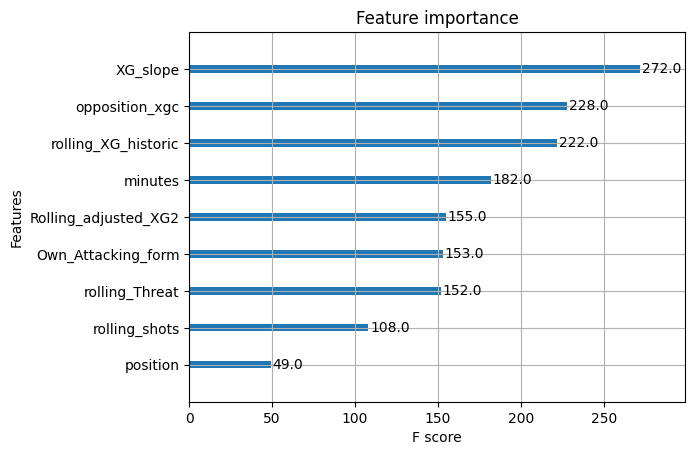

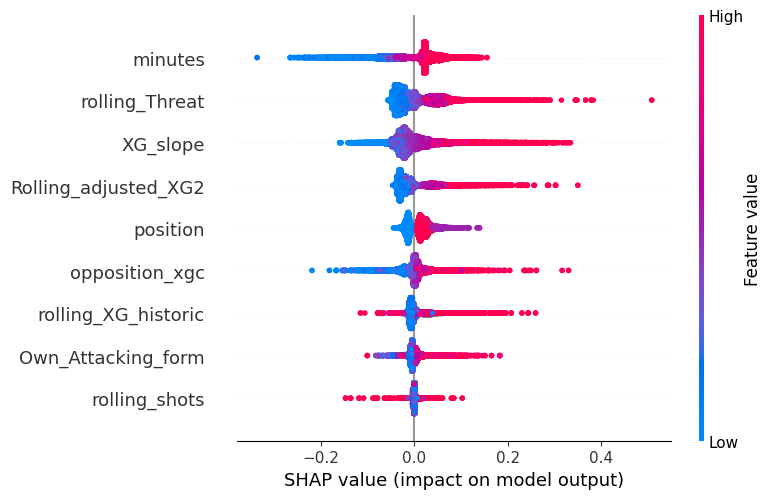

tensor(0.1202, dtype=torch.float64)


C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:51: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opp_xg = data.apply(lambda row: row[22] if row[18] else row[20], axis=1)
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:52: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opp_xgc = data.apply(lambda row: row[23] if row[18] else row[21], axis=1)


[113, 112]
Fábio_Ferreira Vieira
    GW  pred team_name  team_code        XG       XGC        CS
6   37     1   Arsenal          3  1.501614  1.047865  0.256637
37  38     2   Arsenal          3  2.284922  0.720694  0.484417
Gabriel_Fernando de Jesus
    GW  pred team_name  team_code        XG       XGC        CS
6   37     1   Arsenal          3  1.501614  1.047865  0.256637
37  38     2   Arsenal          3  2.284922  0.720694  0.484417
Defensive_factor
105    0.271467
106    0.450341
dtype: float64
Gabriel_dos Santos Magalhães
    GW  pred team_name  team_code        XG       XGC        CS
6   37     1   Arsenal          3  1.501614  1.047865  0.256637
37  38     2   Arsenal          3  2.284922  0.720694  0.484417
Defensive_factor
209    0.271467
210    0.450341
dtype: float64
Kai_Havertz0
    GW  pred team_name  team_code        XG       XGC        CS
6   37     1   Arsenal          3  1.501614  1.047865  0.256637
37  38     2   Arsenal          3  2.284922  0.720694  0.484417
Def

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:86: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XG"]=team_stats["XG"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XGC"]=team_stats["XGC"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

Defensive_factor
2058    0.251105
2059    0.242048
dtype: float64
Lucas_Digne
    GW  pred    team_name  team_code        XG       XGC        CS
0   37     1  Aston Villa          7  1.692867  1.317640  0.274529
34  38     2  Aston Villa          7  1.372697  1.294099  0.252275
Defensive_factor
2153    0.251105
2154    0.242048
dtype: float64
Jhon_Durán
    GW  pred    team_name  team_code        XG       XGC        CS
0   37     1  Aston Villa          7  1.692867  1.317640  0.274529
34  38     2  Aston Villa          7  1.372697  1.294099  0.252275
Defensive_factor
2210    0.251105
2211    0.242048
dtype: float64
Boubacar_Kamara
    GW  pred    team_name  team_code        XG       XGC        CS
0   37     1  Aston Villa          7  1.692867  1.317640  0.274529
34  38     2  Aston Villa          7  1.372697  1.294099  0.252275
Defensive_factor
2280    0.251105
2281    0.242048
dtype: float64
Ezri_Konsa Ngoyo
    GW  pred    team_name  team_code        XG       XGC        CS
0   37    

...

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:86: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XG"]=team_stats["XG"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XGC"]=team_stats["XGC"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

Keylor_Navas
    GW  pred      team_name  team_code        XG       XGC       CS
23  37     1  Nott'm Forest         17  1.216740  1.185377  0.21216
16  38     2  Nott'm Forest         17  1.102547  1.368921  0.24015
Arnaut_Danjuma
    GW  pred team_name  team_code        XG       XGC        CS
20  37     1     Spurs          6  1.317640  1.692867  0.155600
18  38     2     Spurs          6  1.544492  1.556246  0.178464
Sasa_Lukic
    GW  pred team_name  team_code        XG       XGC        CS
24  37     1    Fulham         54  1.389191  1.431415  0.233482
11  38     2    Fulham         54  0.981818  1.589602  0.191126
Matías_Viña
    GW  pred    team_name  team_code        XG       XGC        CS
29  37     1  Bournemouth         91  1.098736  1.837518  0.128974
10  38     2  Bournemouth         91  1.946894  0.891951  0.356281
Weston_McKennie
   GW  pred team_name  team_code   XG  XGC   CS
0  -1    -1        -1         -1 -1.0 -1.0 -1.0
1  -1    -1        -1         -1 -1.0 -1.0 -1.0


C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:86: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XG"]=team_stats["XG"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XGC"]=team_stats["XGC"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

expected_assists


C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:325: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extra['name'] = extra['name'].astype(str) + 'r'
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:326: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extra['name'] = extra['name'].astype('category')
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:331: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

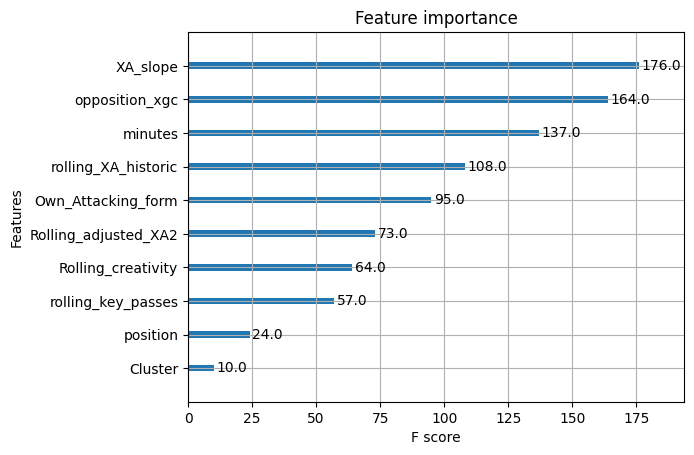

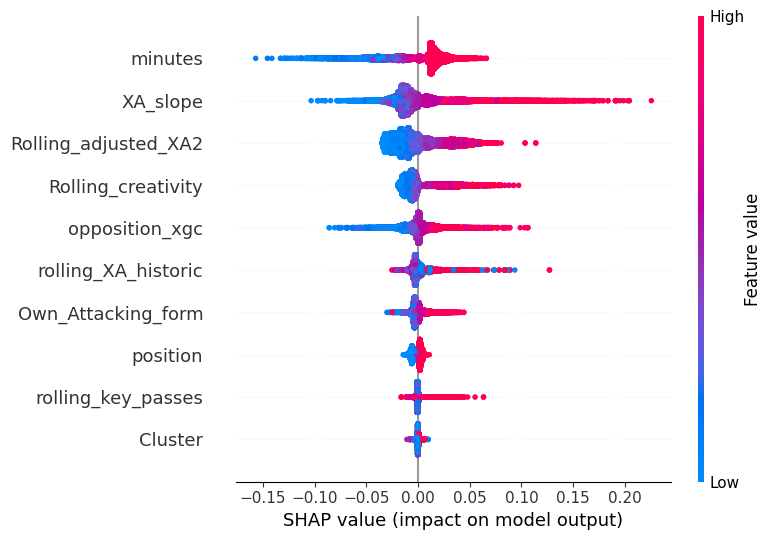

tensor(0.0919, dtype=torch.float64)


C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:51: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opp_xg = data.apply(lambda row: row[22] if row[18] else row[20], axis=1)
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:52: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opp_xgc = data.apply(lambda row: row[23] if row[18] else row[21], axis=1)


[113, 112]
Fábio_Ferreira Vieira
    GW  pred team_name  team_code        XG       XGC        CS
6   37     1   Arsenal          3  1.501614  1.047865  0.256637
37  38     2   Arsenal          3  2.284922  0.720694  0.484417
Gabriel_Fernando de Jesus
    GW  pred team_name  team_code        XG       XGC        CS
6   37     1   Arsenal          3  1.501614  1.047865  0.256637
37  38     2   Arsenal          3  2.284922  0.720694  0.484417
Defensive_factor
105    0.271467
106    0.450341
dtype: float64
Gabriel_dos Santos Magalhães
    GW  pred team_name  team_code        XG       XGC        CS
6   37     1   Arsenal          3  1.501614  1.047865  0.256637
37  38     2   Arsenal          3  2.284922  0.720694  0.484417
Defensive_factor
209    0.271467
210    0.450341
dtype: float64
Kai_Havertz0
    GW  pred team_name  team_code        XG       XGC        CS
6   37     1   Arsenal          3  1.501614  1.047865  0.256637
37  38     2   Arsenal          3  2.284922  0.720694  0.484417
Def

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:86: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XG"]=team_stats["XG"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XGC"]=team_stats["XGC"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

Kieran_Tierney
    GW  pred team_name  team_code        XG       XGC        CS
6   37     1   Arsenal          3  1.501614  1.047865  0.256637
37  38     2   Arsenal          3  2.284922  0.720694  0.484417
Defensive_factor
1236    0.271467
1237    0.450341
dtype: float64
Leandro_Trossard0
    GW  pred team_name  team_code        XG       XGC        CS
6   37     1   Arsenal          3  1.501614  1.047865  0.256637
37  38     2   Arsenal          3  2.284922  0.720694  0.484417
Defensive_factor
1328    0.271467
1329    0.450341
dtype: float64
Leandro_Trossard1
    GW  pred team_name  team_code        XG       XGC        CS
7   37     1  Brighton         36  1.176975  1.820628  0.150001
38  38     2  Brighton         36  1.556246  1.544492  0.182001
Benjamin_White
    GW  pred team_name  team_code        XG       XGC        CS
6   37     1   Arsenal          3  1.501614  1.047865  0.256637
37  38     2   Arsenal          3  2.284922  0.720694  0.484417
Defensive_factor
1438    0.271467


...

Jack_Colback
    GW  pred      team_name  team_code        XG       XGC       CS
23  37     1  Nott'm Forest         17  1.216740  1.185377  0.21216
16  38     2  Nott'm Forest         17  1.102547  1.368921  0.24015
Romain_Perraud
    GW  pred    team_name  team_code        XG       XGC        CS
22  37     1  Southampton         20  0.739555  1.750351  0.112514
17  38     2  Southampton         20  0.720694  2.284922  0.054405
João_Filipe Iria Santos Moutinho
    GW  pred team_name  team_code        XG       XGC        CS
28  37     1    Wolves         39  1.019116  1.338693  0.201160
19  38     2    Wolves         39  1.063408  1.347919  0.207949
Çaglar_Söyüncü
    GW  pred  team_name  team_code        XG       XGC        CS
5   37     1  Leicester         13  1.426340  1.430756  0.132796
30  38     2  Leicester         13  0.891951  1.946894  0.088615
Joel_Robles
   GW  pred team_name  team_code   XG  XGC   CS
0  -1    -1        -1         -1 -1.0 -1.0 -1.0
1  -1    -1        -1   

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:154: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opp_xg = df.apply(lambda row: row[22] if row[18] else row[20], axis=1)
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:155: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opp_xgc = df.apply(lambda row: row[23] if row[18] else row[21], axis=1)


expected_goals_conceded


C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:325: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extra['name'] = extra['name'].astype(str) + 'r'
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:326: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extra['name'] = extra['name'].astype('category')
C:\Users\OleJacobSimensen\OneDrive - twoday\Documents\Python_test\venv\Lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y

Gabriel_dos Santos Magalhães
Gabriel_dos Santos Magalhães
Gabriel_dos Santos Magalhães
Gabriel_dos Santos Magalhães
Gabriel_dos Santos Magalhães
Gabriel_dos Santos Magalhães
Gabriel_dos Santos Magalhães
Gabriel_dos Santos Magalhães
Matty_Cash
Matty_Cash
Matty_Cash
Matty_Cash
Matty_Cash
Matty_Cash
Matty_Cash
Matty_Cash
Matty_Cash
James_Hill
James_Hill
James_Hill
James_Hill
James_Hill
James_Hill
James_Hill
James_Hill
James_Hill
Kristoffer_Ajer
Kristoffer_Ajer
Rayan_Aït-Nouri
Kristoffer_Ajer
Kristoffer_Ajer
Kristoffer_Ajer
Kristoffer_Ajer
Kristoffer_Ajer
Kristoffer_Ajer
Kristoffer_Ajer
Lewis_Dunk
Lewis_Dunk
Lewis_Dunk
Lewis_Dunk
Lewis_Dunk
Lewis_Dunk
Lewis_Dunk
Lewis_Dunk
Lewis_Dunk
Lewis_Dunk
Benoît_Badiashile
Benoît_Badiashile
Trevoh_Chalobah0
Benoît_Badiashile
Lewis_Dunk
Benoît_Badiashile
Benoît_Badiashile
Matty_Cash
Benoît_Badiashile
Benoît_Badiashile
Benoît_Badiashile
Benoît_Badiashile
Joachim_Andersen0
Benoît_Badiashile
Benoît_Badiashile
Trevoh_Chalobah0
Benoît_Badiashile
Trevoh_Cha

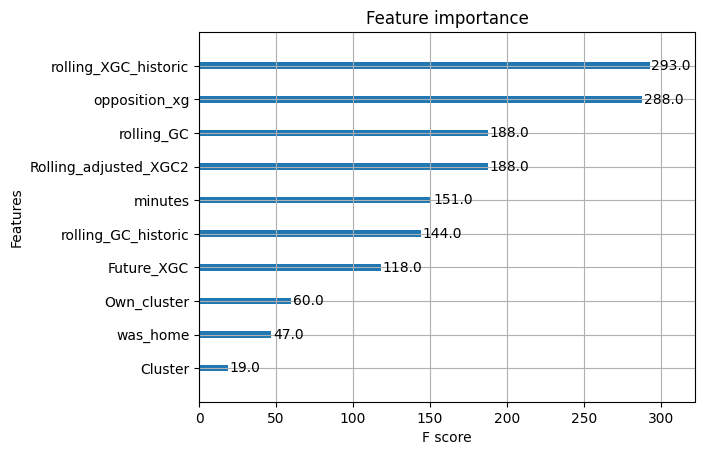

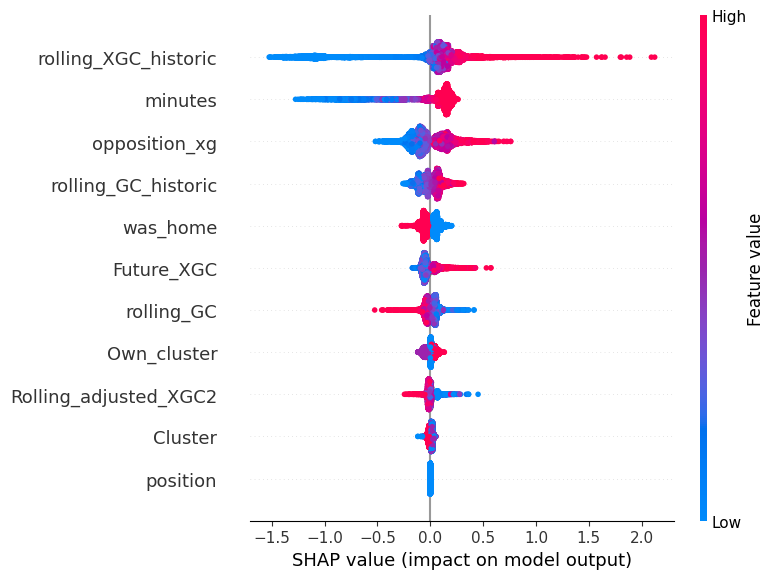

tensor(0.7488, dtype=torch.float64)


C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:51: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opp_xg = data.apply(lambda row: row[22] if row[18] else row[20], axis=1)
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:52: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opp_xgc = data.apply(lambda row: row[23] if row[18] else row[21], axis=1)


[113, 112]
Fábio_Ferreira Vieira
    GW  pred team_name  team_code        XG       XGC        CS
6   37     1   Arsenal          3  1.501614  1.047865  0.256637
37  38     2   Arsenal          3  2.284922  0.720694  0.484417
Gabriel_Fernando de Jesus
    GW  pred team_name  team_code        XG       XGC        CS
6   37     1   Arsenal          3  1.501614  1.047865  0.256637
37  38     2   Arsenal          3  2.284922  0.720694  0.484417
Defensive_factor
105    0.271467
106    0.450341
dtype: float64
Gabriel_dos Santos Magalhães
    GW  pred team_name  team_code        XG       XGC        CS
6   37     1   Arsenal          3  1.501614  1.047865  0.256637
37  38     2   Arsenal          3  2.284922  0.720694  0.484417
Defensive_factor
209    0.271467
210    0.450341
dtype: float64
Kai_Havertz0
    GW  pred team_name  team_code        XG       XGC        CS
6   37     1   Arsenal          3  1.501614  1.047865  0.256637
37  38     2   Arsenal          3  2.284922  0.720694  0.484417
Def

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:86: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XG"]=team_stats["XG"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XGC"]=team_stats["XGC"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

Benjamin_White
    GW  pred team_name  team_code        XG       XGC        CS
6   37     1   Arsenal          3  1.501614  1.047865  0.256637
37  38     2   Arsenal          3  2.284922  0.720694  0.484417
Defensive_factor
1438    0.271467
1439    0.450341
dtype: float64
Oleksandr_Zinchenko
    GW  pred team_name  team_code        XG       XGC        CS
6   37     1   Arsenal          3  1.501614  1.047865  0.256637
37  38     2   Arsenal          3  2.284922  0.720694  0.484417
Defensive_factor
1508    0.271467
1509    0.450341
dtype: float64
Raheem_Sterling0
    GW  pred team_name  team_code        XG       XGC        CS
6   37     1   Arsenal          3  1.501614  1.047865  0.256637
37  38     2   Arsenal          3  2.284922  0.720694  0.484417
Defensive_factor
1526    0.271467
1527    0.450341
dtype: float64
Raheem_Sterling1
    GW  pred team_name  team_code        XG       XGC        CS
1   37     1   Chelsea          8  1.570281  1.073802  0.352158
36  38     2   Chelsea       

...

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:86: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XG"]=team_stats["XG"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XGC"]=team_stats["XGC"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

Matías_Viña
    GW  pred    team_name  team_code        XG       XGC        CS
29  37     1  Bournemouth         91  1.098736  1.837518  0.128974
10  38     2  Bournemouth         91  1.946894  0.891951  0.356281
Weston_McKennie
   GW  pred team_name  team_code   XG  XGC   CS
0  -1    -1        -1         -1 -1.0 -1.0 -1.0
1  -1    -1        -1         -1 -1.0 -1.0 -1.0
Mateus_Cardoso Lemos Martins
    GW  pred  team_name  team_code        XG       XGC        CS
5   37     1  Leicester         13  1.426340  1.430756  0.132796
30  38     2  Leicester         13  0.891951  1.946894  0.088615
Marcel_Sabitzer
    GW  pred team_name  team_code        XG       XGC        CS
21  37     1   Man Utd          1  1.073802  1.570281  0.157834
14  38     2   Man Utd          1  1.294099  1.372697  0.190869
André_Ayew
    GW  pred      team_name  team_code        XG       XGC       CS
23  37     1  Nott'm Forest         17  1.216740  1.185377  0.21216
16  38     2  Nott'm Forest         17  1.102547

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:86: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XG"]=team_stats["XG"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XGC"]=team_stats["XGC"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

bonus


C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:325: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extra['name'] = extra['name'].astype(str) + 'r'
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:326: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extra['name'] = extra['name'].astype('category')
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:331: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

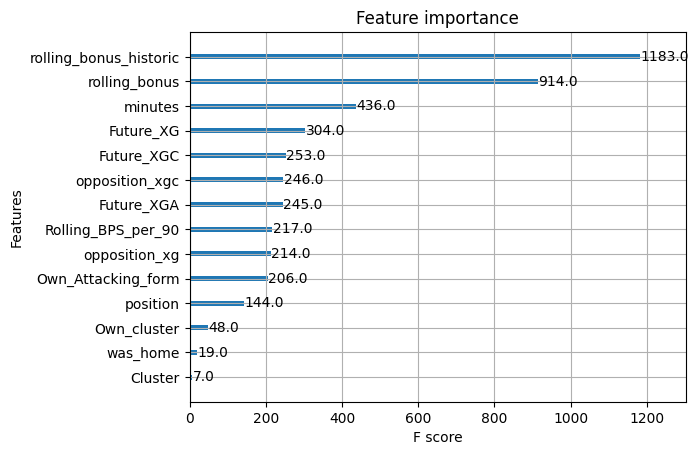

tensor(0.2921, dtype=torch.float64)


C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:51: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opp_xg = data.apply(lambda row: row[22] if row[18] else row[20], axis=1)
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:52: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opp_xgc = data.apply(lambda row: row[23] if row[18] else row[21], axis=1)


[113, 112]
Fábio_Ferreira Vieira
    GW  pred team_name  team_code        XG       XGC        CS
6   37     1   Arsenal          3  1.501614  1.047865  0.256637
37  38     2   Arsenal          3  2.284922  0.720694  0.484417
Gabriel_Fernando de Jesus
    GW  pred team_name  team_code        XG       XGC        CS
6   37     1   Arsenal          3  1.501614  1.047865  0.256637
37  38     2   Arsenal          3  2.284922  0.720694  0.484417
Defensive_factor
105    0.271467
106    0.450341
dtype: float64
Gabriel_dos Santos Magalhães
    GW  pred team_name  team_code        XG       XGC        CS
6   37     1   Arsenal          3  1.501614  1.047865  0.256637
37  38     2   Arsenal          3  2.284922  0.720694  0.484417
Defensive_factor
209    0.271467
210    0.450341
dtype: float64
Kai_Havertz0
    GW  pred team_name  team_code        XG       XGC        CS
6   37     1   Arsenal          3  1.501614  1.047865  0.256637
37  38     2   Arsenal          3  2.284922  0.720694  0.484417
Def

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:86: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XG"]=team_stats["XG"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XGC"]=team_stats["XGC"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

Matty_Cash
    GW  pred    team_name  team_code        XG       XGC        CS
0   37     1  Aston Villa          7  1.692867  1.317640  0.274529
34  38     2  Aston Villa          7  1.372697  1.294099  0.252275
Defensive_factor
1940    0.251105
1941    0.242048
dtype: float64
Leander_Dendoncker0
    GW  pred    team_name  team_code        XG       XGC        CS
0   37     1  Aston Villa          7  1.692867  1.317640  0.274529
34  38     2  Aston Villa          7  1.372697  1.294099  0.252275
Leander_Dendoncker1
    GW  pred team_name  team_code        XG       XGC        CS
28  37     1    Wolves         39  1.019116  1.338693  0.201160
19  38     2    Wolves         39  1.063408  1.347919  0.207949
Moussa_Diaby
    GW  pred    team_name  team_code        XG       XGC        CS
0   37     1  Aston Villa          7  1.692867  1.317640  0.274529
34  38     2  Aston Villa          7  1.372697  1.294099  0.252275
Diego_Carlos Santos Silva
    GW  pred    team_name  team_code        XG   

...

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:86: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XG"]=team_stats["XG"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XGC"]=team_stats["XGC"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

Weston_McKennie
   GW  pred team_name  team_code   XG  XGC   CS
0  -1    -1        -1         -1 -1.0 -1.0 -1.0
1  -1    -1        -1         -1 -1.0 -1.0 -1.0
Mateus_Cardoso Lemos Martins
    GW  pred  team_name  team_code        XG       XGC        CS
5   37     1  Leicester         13  1.426340  1.430756  0.132796
30  38     2  Leicester         13  0.891951  1.946894  0.088615
Marcel_Sabitzer
    GW  pred team_name  team_code        XG       XGC        CS
21  37     1   Man Utd          1  1.073802  1.570281  0.157834
14  38     2   Man Utd          1  1.294099  1.372697  0.190869
André_Ayew
    GW  pred      team_name  team_code        XG       XGC       CS
23  37     1  Nott'm Forest         17  1.216740  1.185377  0.21216
16  38     2  Nott'm Forest         17  1.102547  1.368921  0.24015


C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:86: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XG"]=team_stats["XG"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XGC"]=team_stats["XGC"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

total_points


C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:325: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extra['name'] = extra['name'].astype(str) + 'r'
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:326: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extra['name'] = extra['name'].astype('category')
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\2427793236.py:331: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

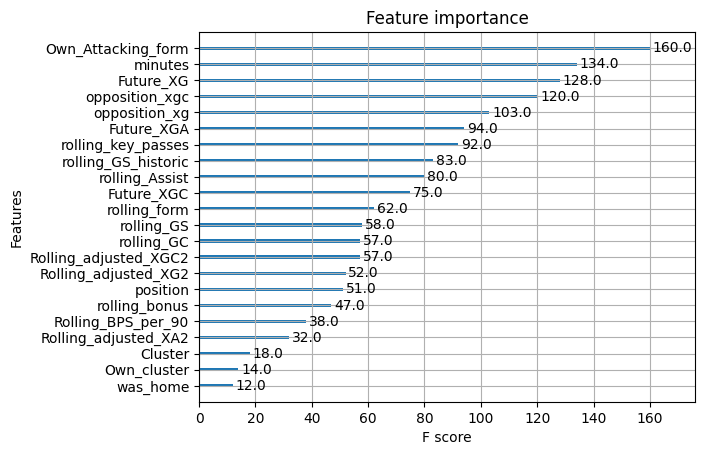

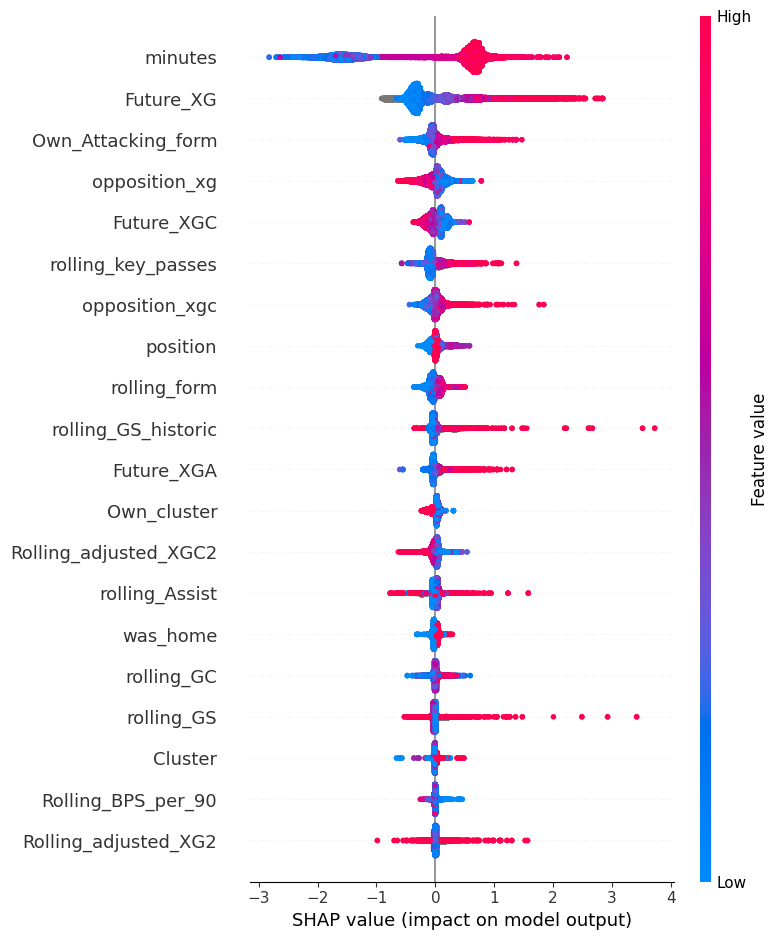

tensor(2.2996)


In [314]:

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from datetime import datetime, timedelta
from sklearn.preprocessing import LabelEncoder
import pytz
import torch.nn as nn
import torch
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import load_model
from tensorflow.keras.models import load_model
from tensorflow.keras.losses import MeanSquaredError
from sklearn.svm import SVR

criterion = nn.L1Loss()
df=pd.read_csv("testML3.csv").iloc[:,1:]
max_t=df['time'].max()
print(max_t)
names= df['name'].unique()
print(names)
time_df=pd.DataFrame()
for i in range(len(names)):
    name=names[i]
    first_filtered= df[df['name'] == name]
    unique_teamvals= first_filtered['Team'].unique()
    for t in range(len(unique_teamvals)):
        team=unique_teamvals[t]
        new_filtered= first_filtered[first_filtered['Team'] == team]
        times=[]
        filtered = new_filtered[new_filtered["minutes"] > 0]
        for g in range(len(filtered)):
            times.append(max_t-g)
        times.reverse()
        filtered["time"]=times
        if(len(unique_teamvals)>1):
            filtered['name']=filtered['name'].values[0]+str(t)
        time_df=pd.concat([time_df, filtered], axis=0, ignore_index=True)

time_df.to_csv("ML_training2.csv")
def Stat_preds(is_pred, pred_variable,column_list,horizon):
    horizon=horizon
    data=pd.read_csv("ML_training2.csv").iloc[:,1:]
    team_data=pd.read_csv("Team_prediction.csv").iloc[:,1:]
    max_time=data["time"].max()
    if(is_pred==0):
        max_time=max_time-horizon
    time_list=list(range(max_time, max_time-horizon, -1))
    opp_xg = data.apply(lambda row: row[22] if row[18] else row[20], axis=1)
    opp_xgc = data.apply(lambda row: row[23] if row[18] else row[21], axis=1)
    data["opposition_xg"]=opp_xg
    data["opposition_xgc"]=opp_xgc
    data['rolling_Threat'] = data['rolling_Threat'].fillna(10)
    data['rolling_key_passes'] = data['rolling_key_passes'].fillna(0.5)
    data['rolling_ICT'] = data['rolling_ICT'].fillna(5)
    data['Rolling_creativity'] = data['Rolling_creativity'].fillna(10)
    
    
    pred_data=data[data['time'].isin(time_list)]
    print(time_list)
    players=data["name"].unique()
    all_preds=[]
    MSE=[]
    for i in range(len(players)):
        print(players[i])
        preds=[]
        val_preds=[]
        val_real=[]
        df=pred_data[pred_data["name"]==players[i]]
        team=df['Team'].values[-1]
        team_stats=team_data[team_data["team_code"]==team].sort_values(by='pred')
        rows_missing = horizon - len(team_stats)

        if rows_missing > 0:
            # Create a DataFrame with the required number of zero-filled rows
            zero_row = pd.DataFrame(-1, index=range(rows_missing), columns=team_stats.columns)
    
            # Concatenate to your original DataFrame
            team_stats = pd.concat([team_stats, zero_row], ignore_index=True)
        print(team_stats)
        if(len(team_stats)<1):
            continue
            
        df["team_XG"]=team_stats["XG"].values[:horizon]
        df["team_XGC"]=team_stats["XGC"].values[:horizon]
        df["team_CS"]=team_stats["CS"].values[:horizon]
        df=df.sort_values(by='time')
        df2=data[data["name"]==players[i]]
        season_filter=df2[(df2['season'] == 25)]
        if(len(season_filter)<1):
            continue

        attacking_factor=(df["opposition_xgc"]+df['team_XG'])*0.5
        defensive_factor=(df["team_CS"]+0.3/df["team_XGC"])*0.5
        print("Defensive_factor")
        print(defensive_factor)
        if(pred_variable=="GOALS"):
           print(df['rolling_Threat']) 
           df["pred"]=(df['Rolling_adjusted_XG2']+df['rolling_Threat']/100)*(attacking_factor)*0.5
           real_variable="expected_goals" 
        if(pred_variable=="Assist"):
           real_variable="expected_assists"  
           df["pred"]=(df['Rolling_adjusted_XA2']+(df['Rolling_creativity']/200))*(attacking_factor)*0.5
            
        if(pred_variable=="GC"):
            real_variable="expected_goals_conceded"
            if(df["position"].values[0] in ["FWD"]):
                continue
            team=df['Team'].values[-1]
            time_filter = data[(data['season'] == 25)]
            team_filter=time_filter[time_filter["Team"]==team]
            team_filter = team_filter.groupby('name')['minutes'].sum().reset_index()
            if(len(team_filter)<1):
                continue
            else:
                player_with_most_minutes = team_filter.loc[team_filter['minutes'].idxmax(), 'name']
                filtered_df=data[data["name"]==player_with_most_minutes]
                filtered_df = filtered_df[(filtered_df['season'] == 30)]

            df["pred"]=defensive_factor.values
            
        if(pred_variable=="bps"):
           real_variable="bonus" 
           df["pred"]=df['Rolling_adjusted_BPS2']*0.04
        
        if(pred_variable=="Fantasy"):
           real_variable="total_points"  
           df["pred"]=df['Rolling_adjusted_Fantasy2']*(df['team_XG'])
            
        preds.append(df["name"].values[0])
        df["pred"]=df["pred"].round(2)
        #if(df['pred'].isna().any()):
            #continue
        for r in range(len(df.values)):
            preds.append(df["pred"].values[r])
            val_preds.append(df["pred"].values[r])
            val_real.append(df[real_variable].values[r])
            
        preds.append(df["position"].values[0])
        all_preds.append(preds)
        #MSE.append(mean_squared_error(val_real, val_preds))
        
    columns=column_list
    data_f=pd.DataFrame(all_preds, columns=columns)
    data_f.to_csv(f"STAT_{pred_variable}_preds2.csv", index=False)
    #print(sum(MSE) / len(MSE))
def XGB_Make_dataset(position,position2):
    df=pd.read_csv("ML_training2.csv").iloc[:,1:]
    #df=df[df['position'] == position2]
    if(position in['Assist','GOALS']):
        df = df.dropna(subset=['XG_Mean_difference', 'XA_Mean_difference'])
    opp_xg = df.apply(lambda row: row[22] if row[18] else row[20], axis=1)
    opp_xgc = df.apply(lambda row: row[23] if row[18] else row[21], axis=1)

    df["opposition_xg"]=opp_xg
    df["opposition_xgc"]=opp_xgc

    trainingdf=df[["Cluster_XG","Cluster_XA","Threat_slope","XA_slope","XG_slope","minutes","season","opposition_xg","Average_Overscore","opposition_xgc", "rolling_form","rolling_XG","Team","name","position","Own_cluster","Cluster"
                   ,"was_home","total_points","rolling_GS","rolling_GC","rolling_XA","time","gamepos","rolling_ICT","Overscore","XGC_DEF","XGC_FWD","XGC_MID"
                   ,"Rolling_adjusted_XG2","Rolling_adjusted_XGC2","Rolling_adjusted_XA2","rolling_GS_historic","rolling_XG_historic","goals_scored","expected_goals"
                  ,"assists","rolling_Assist_historic","rolling_Assist","rolling_XA_historic","expected_assists","rolling_GC_historic","rolling_XGC_historic","clean_sheets",
                   "expected_goals_conceded", "rolling_bps","rolling_bps_historic","rolling_bonus_historic","rolling_bonus","bonus","rolling_key_passes","rolling_shots","Own_Attacking_form","Rolling_BPS_per_90"
                  ,"XG_Mean_difference","XA_Mean_difference","Shot_Mean_difference","Adjusted_XG_Mean_difference","Threat_Mean_difference","rolling_Threat","XG_Mean","Rolling_creativity"]]
    
    
    names= df['name'].unique()
    time_df=pd.DataFrame()
    for i in range(len(names)):
        times=[]
        name=names[i]
        filtered= trainingdf[trainingdf['name'] == name].copy()
        filtered['rolling_XG'] = filtered['rolling_XG'].shift(1)
        filtered['rolling_GC'] = filtered['rolling_GC'].shift(1)
        filtered['rolling_XA'] = filtered['rolling_XA'].shift(1)
        filtered['rolling_GS_historic'] = filtered['rolling_GS_historic'].shift(1)
        filtered['rolling_XG_historic'] = filtered['rolling_XG_historic'].shift(1)
        filtered['rolling_XA_historic'] = filtered['rolling_XA_historic'].shift(1)
        filtered['rolling_Assist'] = filtered['rolling_Assist'].shift(1)
        filtered['rolling_Assist_historic'] = filtered['rolling_Assist_historic'].shift(1)
        filtered['rolling_bps'] = filtered['rolling_bps'].shift(1)
        #filtered['Rolling_adjusted_XGC'] = filtered['Rolling_adjusted_XGC'].shift(1)
        #filtered['Rolling_adjusted_XG'] = filtered['Rolling_adjusted_XG'].shift(1)
        filtered['Overscore'] = filtered['Overscore'].shift(1)
        filtered['Capped_Average_Overscore'] = np.clip(df['Average_Overscore'], None, 1.5)
        filtered['Future_XG'] = filtered['Rolling_adjusted_XG2']*filtered['opposition_xgc']
        filtered['Future_XG2'] = filtered['Rolling_adjusted_XG2']*(filtered['opposition_xgc']*0.8+0.1*filtered['Own_Attacking_form']**2)
        
        filtered['Future_XGC'] = filtered['Rolling_adjusted_XGC2']*filtered['opposition_xg']
        filtered['Future_XGA'] = filtered['Rolling_adjusted_XA2']*filtered['opposition_xgc']
        filtered['XG_diff'] = filtered["rolling_XG"]-filtered['rolling_XG_historic']
        filtered['XA_diff'] = filtered["rolling_XA"]-filtered['rolling_XA_historic']
        filtered['opposition_xgc_bucket'] = pd.cut(filtered['opposition_xgc'],bins=[0, 0.8, 1, 1.2,1.3 ,1.4,1.5 ,1.6, 1.8, 2, 3],labels=[0.4, 0.9, 1.1, 1.2,1.3, 1.5,1.6, 1.7, 1.9, 2.5],include_lowest=True)
        filtered['opposition_xg_bucket'] = pd.cut(filtered['opposition_xg'],bins=[0, 0.8, 1, 1.2,1.3 ,1.4,1.5 ,1.6, 1.8, 2, 3],labels=[0.4, 0.9, 1.1, 1.2,1.3, 1.5,1.6, 1.7, 1.9, 2.5],include_lowest=True)

        filtered['Own_Attacking_form_bucket'] = pd.cut(filtered['Own_Attacking_form'],bins=[0, 0.8, 1, 1.2,1.3 ,1.4,1.5 ,1.6, 1.8, 2, 3],labels=[0.4, 0.9, 1.1, 1.2,1.3, 1.5,1.6, 1.7, 1.9, 2.5],include_lowest=True)
        # Convert to numeric (this removes the categorical dtype)
   
        time_df=pd.concat([time_df, filtered], axis=0, ignore_index=True)
    trainingdf=time_df
    trainingdf['Team'] = trainingdf['Team'].astype('category')
    trainingdf['name'] = trainingdf['name'].astype('category')
    trainingdf['opposition_xgc_bucket'] = trainingdf['opposition_xgc_bucket'].astype(float)
    trainingdf['Own_Attacking_form_bucket'] = trainingdf['Own_Attacking_form_bucket'].astype(float)
    trainingdf['opposition_xg_bucket'] = trainingdf['opposition_xg_bucket'].astype(float)
    trainingdf['position'] = trainingdf['position'].astype('category')
    trainingdf['gamepos'] = trainingdf['gamepos'].astype('category')
    trainingdf['Shot_Mean_difference'] = trainingdf['Shot_Mean_difference'].fillna(0)
    trainingdf['Threat_Mean_difference'] = trainingdf['Threat_Mean_difference'].fillna(0)
    trainingdf['Adjusted_XG_Mean_difference'] = trainingdf['Adjusted_XG_Mean_difference'].fillna(0)
    trainingdf['XG_Mean_difference'] = trainingdf['XG_Mean_difference'].clip(lower=-1, upper=2)
    trainingdf['XA_Mean_difference'] = trainingdf['XA_Mean_difference'].clip(lower=-1, upper=3)
    trainingdf.replace([np.inf, -np.inf], 1, inplace=True)
    """if(position=='GOALS'):
        trainingdf=trainingdf[trainingdf['position'].isin(["FWD", "DEF", "MID"])]
        trainingdf=trainingdf[["position","XG_diff","opposition_xgc","Own_Attacking_form","Team","name","Cluster"
                   ,"time","minutes","Shot_Mean_difference","XG_slope","season","XG_Mean_difference","Threat_slope"]]
        target_value="XG_Mean_difference" """
    if(position=='GOALS'):
        trainingdf=trainingdf[trainingdf['position'].isin(["FWD", "DEF", "MID"])]
        trainingdf=trainingdf[["expected_goals","opposition_xgc","Own_Attacking_form","XG_slope","rolling_shots",
                               "Team","name","time","minutes","season","rolling_Threat","position","rolling_XG_historic","Rolling_adjusted_XG2"]]
        target_value="expected_goals"
        
    elif(position=='Assist2'):
        trainingdf=trainingdf[trainingdf['position'].isin(["FWD", "DEF", "MID"])]
        trainingdf=trainingdf[["XA_diff","position","opposition_xgc","Own_Attacking_form","Rolling_adjusted_XA2","Team","name","Own_cluster","Cluster"
                   ,"time","minutes","rolling_XA_historic","XA_Mean_difference","season","rolling_key_passes","XA_slope"]]
        target_value="XA_Mean_difference"
        
    elif(position=='GC'):
        trainingdf=trainingdf[trainingdf['position'] == "DEF"]
        trainingdf=trainingdf[["position","opposition_xg","Rolling_adjusted_XGC2","Team","name","Own_cluster","Cluster"
                   ,"was_home","rolling_GC","time","minutes","Future_XGC","rolling_GC_historic","rolling_XGC_historic","expected_goals_conceded","season"]]
        target_value="expected_goals_conceded"
        
    elif(position=='bps'):
        trainingdf=trainingdf[["opposition_xgc","position","opposition_xg","Own_Attacking_form","rolling_bonus_historic","rolling_bonus","bonus","Team","name","Own_cluster","Cluster"
                   ,"was_home","time","minutes","season","Future_XG","Future_XGA","Future_XGC","Rolling_BPS_per_90"]]
        target_value="bonus"
        
    elif(position=='Fantasy'):
        trainingdf=trainingdf[["total_points","opposition_xg","opposition_xgc","position","Own_Attacking_form","rolling_bonus","Team","name","Own_cluster","Cluster"
                   ,"was_home","time","minutes","season","Future_XG","Future_XGA","Future_XGC","Rolling_adjusted_XA2","rolling_key_passes","rolling_Assist","Rolling_adjusted_XG2"
                    ,"rolling_GS","rolling_GS_historic","Rolling_adjusted_XGC2","rolling_GC","rolling_form","Rolling_BPS_per_90"]]
        target_value="total_points"

    elif(position=='Assist'):
        trainingdf=trainingdf[trainingdf['position'].isin(["FWD", "DEF", "MID"])]
        trainingdf=trainingdf[["expected_assists","opposition_xgc","Own_Attacking_form","XA_slope","rolling_key_passes",
                               "Team","name","time","minutes","season","Rolling_creativity","position","rolling_XA_historic","Cluster","Rolling_adjusted_XA2"]]
        target_value="expected_assists"
        
    elif(position=='GK'):
        trainingdf=trainingdf[["opposition_xg","Team","name","Own_cluster","Cluster"
                   ,"was_home","total_points","rolling_GC","time","gamepos"]]
           

    else:
        trainingdf=trainingdf[["opposition_xg","opposition_xgc", "rolling_form","rolling_XG","Team","name","Own_cluster","Cluster"
                   ,"was_home","total_points","rolling_GS","rolling_XA","time","gamepos",'Future_XG',"Future_XGA"]]
    trainingdf.to_csv("xgb_test_data.csv")
    print(target_value)
    return trainingdf,target_value
    
def XGB_Train(rounds, eta,max_depth,gamma,min_c,dtrain,target_value,train,Y_train  ):
    if(target_value=='bonus'):
        params = {
            'objective': 'multi:softprob',
            'max_depth': max_depth,
            'eta': eta,
            'eval_metric': 'mlogloss',
            'tree_method': 'hist',
            'grow_policy': 'lossguide',
            'lambda': 2,
            'gamma': gamma,
            'min_child_weight': min_c,
            'num_class': 4
        }

        # Train using xgboost.train
        num_rounds = rounds
        xgb_model = xgb.train(params, dtrain, num_rounds)
        return xgb_model

    else:
        params = {
            'max_depth': max_depth,
            'eta': eta,
            'objective': 'reg:squarederror',  # Use 'reg:squarederror' for regression
            'eval_metric': 'rmse',             # Use 'rmse' (root mean squared error) for evaluation
            'tree_method':'hist',
            'grow_policy': 'lossguide',
            'lambda': 2, 
            'gamma':gamma,
            'min_child_weight': min_c
        }

        num_rounds = rounds
        xgb_model = xgb.train(params, dtrain, num_rounds)
        return xgb_model


def XGB_Make_Pred(trainingdf,target_value,position2,column_list,predlength,position):
    X_train=pd.DataFrame()
    names= trainingdf['name'].unique()


    for i in range(len(names)):
        name=names[i]
        filtered= trainingdf[trainingdf['name'] == name]
        training_cutoff = filtered["time"].max() - predlength*2

        name_df=filtered[lambda x: x.time <= training_cutoff]
        X_train=pd.concat([X_train, name_df], axis=0, ignore_index=True)
        
    full=['Mohamed_Salah','Kai_Havertz1','Ollie_Watkins','Antoine_Semenyo','Bryan_Mbeumo','João Pedro_Junqueira de Jesus','Danny_Welbeck','Nicolas_Jackson','Jean-Philippe_Mateta','Dominic_Calvert-Lewin','Diogo_Teixeira da Silva'
      ,'Erling_Haaland','Alexander_Isak','Chris_Wood','Matheus_Santos Carneiro Da Cunha','Dominic_Solanke','Gabriel_dos Santos Magalhães','William_Saliba','Lucas_Digne','Ezri_Konsa Ngoyo','Lewis_Dunk','Levi_Colwill0','Antonee_Robinson','Trent_Alexander-Arnold','Andrew_Robertson',
      'Joško_Gvardiol','Rico_Lewis','Diogo_Dalot Teixeira','Dan_Burn','Pedro_Porro','Rayan_Aït-Nouri','Kai_Havertz0','Gabriel_Martinelli Silva','Bukayo_Saka','Martin_Ødegaard','Morgan_Rogers','Antoine_Semenyo','Marcus_Tavernier','Bryan_Mbeumo','Noni_Madueke',
      'Cole_Palmer0','Eberechi_Eze','Dwight_McNeil','Diogo_Teixeira da Silva','Luis_Díaz','Mohamed_Salah','Phil_Foden','Bruno_Borges Fernandes','Marcus_Rashford','Harvey_Barnes1','Anthony_Gordon0',
      'Morgan_Gibbs-White0','Brennan_Johnson0','Dejan_Kulusevski','James_Maddison1','Jarrod_Bowen']
    
    extra=X_train[X_train['name'].isin(full)]
    extra['name'] = extra['name'].astype(str) + 'r'
    extra['name'] = extra['name'].astype('category')
    X_train=pd.concat([X_train, extra], axis=0, ignore_index=True)

    full=['Mohamed_Salah']
    extra=X_train[X_train['name'].isin(full)]
    extra['name'] = extra['name'].astype(str) + 'r2'
    extra['name'] = extra['name'].astype('category')
    X_train=pd.concat([X_train, extra], axis=0, ignore_index=True)
    
    X_test=pd.DataFrame()

    max_cutoff=predlength
    min_cutoff=0
    for i in range(len(names)):
        name=names[i]
        filtered= trainingdf[trainingdf['name'] == name]
        training_cutoff = filtered["time"].max() - max_cutoff
        training_cutoff2 = filtered["time"].max() - min_cutoff
        name_df=filtered[lambda x: x.time > training_cutoff]
        name_df=name_df[lambda x: x.time <= training_cutoff2]
        X_test=pd.concat([X_test, name_df], axis=0, ignore_index=True)

    total=[]
    
    Y_train=X_train[[target_value]]
    Y_test=X_test[[target_value]]

    train = X_train.drop(columns=[target_value,'time',"name","Team","season"])
    test = X_test.drop(columns=['time'])

    dtrain = xgb.DMatrix(train, label=Y_train,enable_categorical=True)

    dtest = xgb.DMatrix(test, label=Y_test,enable_categorical=True)



    preds_list=test['name'].unique()
    test.to_csv("Debugg.csv")
    model=XGB_Train(60,0.1,5,0.1,6,dtrain,target_value,train,Y_train )
    model2=SVR(kernel='rbf', C=0.1, epsilon=0.1,gamma=0.1)
    #model2=xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.01, max_depth=5,min_child_weight=6)

    svr_train=train.drop(columns=['position'])
    svr_train=svr_train.fillna(0)
    model2.fit(svr_train,Y_train)
    row2=[]
    actuals=[]
    df2=pd.read_csv("ML_training2.csv").iloc[:,1:]
    for i in range(len(preds_list)):
        row=[]
        player=[]
        player.append(preds_list[i])
        row.append(preds_list[i])
        filtered_df = test[test['name'].isin(player)]
        min_cutoff=max(min_cutoff,1)
        xg_mean=df2[df2['name'].isin(player)]["XG_Mean"]
        xa_mean=df2[df2['name'].isin(player)]["XA_Mean"]
        xg=df2[df2['name'].isin(player)]["expected_goals"]
        xa=df2[df2['name'].isin(player)]["expected_assists"]
        if(target_value=="expected_goals_conceded"):
            team=filtered_df['Team'].values[-1]
            
            team_filter=trainingdf[trainingdf["Team"]==team]
            time_filter = team_filter[team_filter['season'] == 25]
            if(len(time_filter)<1):
                continue
            else:
                player_with_most_minutes = time_filter.loc[time_filter['minutes'].idxmax(), 'name']
                print(player_with_most_minutes)
                filtered_df=test[test["name"]==player_with_most_minutes]
        filtered.drop(columns=['time'])
        y=filtered_df[[target_value]]
        filtered_df = filtered_df.drop(columns=[target_value,'name',"Team","season"])
        dtest = xgb.DMatrix(filtered_df, label=y,enable_categorical=True)
        if(position in ["GOALS","Assist"]):
            svr_test=filtered_df.drop(columns=['position'])
            svr_test=svr_test.fillna(0)
            y_pred = model2.predict(svr_test)
        else:
            y_pred = model.predict(dtest)
        for g in range(len(y_pred)):
            
            if(target_value=="XG_Mean_difference"):
                row.append(y_pred[g]*xg_mean.values[-(max_cutoff-g)]+xg_mean.values[-(max_cutoff-g)])
                row2.append(y_pred[g]*xg_mean.values[-(max_cutoff-g)]+xg_mean.values[-(max_cutoff-g)])
                #row.append(y_pred[g])
                #row2.append(y_pred[g])
            elif(target_value=="XA_Mean_difference"):
                row.append(y_pred[g]*xa_mean.values[-(max_cutoff-g)]+xa_mean.values[-(max_cutoff-g)])
                row2.append(y_pred[g]*xa_mean.values[-(max_cutoff-g)]+xa_mean.values[-(max_cutoff-g)])
                #row.append(y_pred[g])
                #row2.append(y_pred[g])
            elif(target_value=="bonus"):
                row.append(y_pred[g][0]*0+y_pred[g][1]*1+y_pred[g][2]*2+y_pred[g][3]*3)
                row2.append(y_pred[g][0]*0+y_pred[g][1]*1+y_pred[g][2]*2+y_pred[g][3]*3)      
            else:
                row.append(y_pred[g])
                row2.append(y_pred[g])
        for t in range(len(y_pred)):
            if(target_value=="XG_Mean_difference"):
                row.append(xg.values[-(max_cutoff-t)])
                actuals.append(xg.values[-(max_cutoff-t)])
                #row.append(y.values[t][0])
                #actuals.append(y.values[t][0])
            elif(target_value=="XA_Mean_difference"):
                row.append(xa.values[-(max_cutoff-t)])
                actuals.append(xa.values[-(max_cutoff-t)])
                #row.append(y.values[t][0])
                #actuals.append(y.values[t][0])

            else:
                row.append(y.values[t][0])
                actuals.append(y.values[t][0])

        row.append(filtered_df["position"].values[0])
        total.append(row)
    from xgboost import plot_importance
    import matplotlib.pyplot as plt
    import shap

    le = LabelEncoder()
    train['position'] = le.fit_transform(train['position'])
    # Plot feature importance
    plot_importance(model, importance_type='weight')
    plt.show()
    if(target_value!="bonus"):
        explainer = shap.Explainer(model)

        # Compute SHAP values
        shap_values = explainer(train)  # X is your feature matrix
        shap.summary_plot(shap_values, train)
    
    print(criterion(torch.tensor(row2), torch.tensor(actuals)))
    column_list = []
    column_list.append("Name")
    for s in range(predlength):
        column_list.append(f"p{s+1}")
    for e in range(predlength):
        column_list.append(f"y{e+1}")
    column_list.append("position")
    columns=column_list
    data_f=pd.DataFrame(total, columns=columns)
    return data_f
    
def XGB(position,position2,column_list,predlength):
    data,target_value=XGB_Make_dataset(position,position2)
    pred=XGB_Make_Pred(data,target_value,position2,column_list,predlength,position)
    return pred
def Generate_LSTM_preds(pred,column_list,predlength):
    if(pred in ["GC","Fantasy"]):
        return 0
    data=pd.read_csv("ML_training2.csv").iloc[:,1:]
    opp_xg = data.apply(lambda row: row[22] if row[18] else row[20], axis=1)
    opp_xgc = data.apply(lambda row: row[23] if row[18] else row[21], axis=1)
    data["opposition_xg"]=opp_xg
    data["opposition_xgc"]=opp_xgc
    unique_players=data["name"].unique()
    pred_all_players=pd.DataFrame(columns=column_list)
    window=8
    future=predlength
    for k in range(len(unique_players)):
        pred_player_df=[]
        player_name=unique_players[k]
        
        pred_player_df.append(player_name)
        
        df=data[data["name"]==unique_players[k]]
        position=df["position"].values[-1]
        past_df=df[df["season"]!=30].sort_values(by="time", ascending=True)

        test_df=df[df["season"]==25]
        if(len(test_df)<1):
            continue
        
        if(pred=="GOALS"):
            past_columns=["minutes","shots","Threat","expected_goals"]
            past_columns=["minutes","rolling_XG_historic","Threat","expected_goals"]
            future_columns=["opposition_xgc","Own_Attacking_form"]
            pred_variable="expected_goals"
            model_path="LSTM_Goals2.h5"
        elif(pred=="Assist"):
            past_columns=["minutes","key_passes","creativity","expected_assists"]
            future_columns=["opposition_xgc","Own_Attacking_form"]
            pred_variable="expected_assists"
            model_path="LSTM_Assist2.h5"
        elif(pred=="bps"):
            past_columns=["minutes","ICT","total_points","bonus"]
            future_columns=["opposition_xgc","Own_Attacking_form"]
            pred_variable="bonus"
            model_path="LSTM_Bonus.h5"



        past_df=past_df[past_columns]

        past_scaler = MinMaxScaler(feature_range=(0, 1))
        past_scaler.fit(data[past_columns].to_numpy())
        past_df[past_columns]=past_scaler.transform(past_df[past_columns].to_numpy())

        
        if len(past_df) < window:
            num_missing = window - len(past_df)
            zero_rows = pd.DataFrame(np.zeros((num_missing, past_df.shape[1])), columns=past_df.columns)
            past_df = pd.concat([zero_rows, past_df], ignore_index=True)

        opp_xg = df.apply(lambda row: row[22] if row[18] else row[20], axis=1)
        opp_xgc = df.apply(lambda row: row[23] if row[18] else row[21], axis=1)
        df["opposition_xg"]=opp_xg
        df["opposition_xgc"]=opp_xgc

        future_scaler = MinMaxScaler(feature_range=(0, 1))
        
        future_scaler.fit(data[future_columns].to_numpy())
        df[future_columns]=future_scaler.transform(df[future_columns].to_numpy())
    
        

        future_data=df[df["season"]==30].sort_values(by="time", ascending=True)
        future_data=future_data[future_columns]
        
        if len(future_data) < future:
            num_missing = future - len(future_data)
            zero_rows = pd.DataFrame(np.zeros((num_missing, future_data.shape[1])), columns=future_data.columns)
            future_data = pd.concat([zero_rows, future_data], ignore_index=True)

        
        future=len(future_data)

        past_df=past_df.iloc[-window:,:]

        X_test=[]
        X_future=[]
        for i in range(future): 
            X_test.append(past_df.values)
            X_future.append([future_data.values[i]])

        X_test = np.array(X_test)
        X_future = np.array(X_future)

        if(player_name=="Mohamed_Salah"):
            print(X_test)
            print(X_future)
        # Load the model
        model = load_model(model_path, compile=False)

        # Compile again with the correct loss function
        model.compile(optimizer='adam', loss=MeanSquaredError()) 


        predictions = model.predict([X_test, X_future])

        y_pred_rescaled = past_scaler.inverse_transform(
            np.concatenate((np.zeros((len(predictions), len(past_columns) - 1)), predictions.reshape(-1, 1)), axis=1)
        )[:, -1]
        print(y_pred_rescaled)
        for y in range(len(y_pred_rescaled)):
            pred_player_df.append(y_pred_rescaled[y])
        pred_player_df.append(position)
        append_df=pd.DataFrame([pred_player_df], columns=column_list)
        pred_all_players = pd.concat([pred_all_players, append_df], ignore_index=True)

    pred_all_players.to_csv(f"LSTM_{pred}.csv") 
def Make_Predictions ():
    predlength=2
    is_pred=1
    column_list = []
    column_list.append("Name")
    for k in range(predlength):
        column_list.append(f"p{k+1}")
    column_list.append("position")
    positions=["GOALS", "Assist","GC","bps","Fantasy"]
    #positions=["GOALS", "Assist"]
    for y in range(len(positions)):
        XGB_pred=pd.DataFrame()
        position_filter=positions[y]
        Stat_preds(is_pred, position_filter,column_list,predlength)

        pred2=XGB(position_filter,"FWD",column_list,predlength)
        XGB_pred=pd.concat([XGB_pred, pred2], axis=0, ignore_index=True)
            
        XGB_pred.to_csv(f"XGB_{position_filter}_preds2.csv", index=False)
        #Generate_LSTM_preds(position_filter,column_list,predlength)

if __name__ == '__main__':
    Make_Predictions()
#0.0306
#0.0924

In [ ]:
import pandas as pd
import torch
import torch.nn as nn
criterion = nn.MSELoss()
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
data=pd.read_csv("ML_training2.csv").iloc[:,1:]
opp_xg = data.apply(lambda row: row[22] if row[18] else row[20], axis=1)
opp_xgc = data.apply(lambda row: row[23] if row[18] else row[21], axis=1)
data["opposition_xg"]=opp_xg
data["opposition_xgc"]=opp_xgc
data["FXG"]=data['Rolling_adjusted_XG2']*(data['opposition_xgc']*0.8+0.1*data['Own_Attacking_form']**2)
data["FXA"]=data['Rolling_adjusted_XA2']*(data['opposition_xgc']*0.8+0.1*data['Own_Attacking_form']**2) 
data["Fbs"]=data['Rolling_adjusted_BPS']*(data['opposition_xgc']*0.8+0.1*data['Own_Attacking_form'])
data["Fpoints"]=data['Rolling_adjusted_Fantasy2']*(data['opposition_xgc']*0.8+0.1*data['Own_Attacking_form'])
data=data[data["season"]!= 30]

full=['Kai_Havertz1','Ollie_Watkins','Antoine_Semenyo','Bryan_Mbeumo','João Pedro_Junqueira de Jesus','Danny_Welbeck','Nicolas_Jackson','Jean-Philippe_Mateta','Dominic_Calvert-Lewin','Diogo_Teixeira da Silva'
      ,'Erling_Haaland','Alexander_Isak','Chris_Wood1','Matheus_Santos Carneiro Da Cunha','Dominic_Solanke','Gabriel_dos Santos Magalhães','William_Saliba','Lucas_Digne','Ezri_Konsa Ngoyo','Lewis_Dunk','Levi_Colwill0','Antonee_Robinson','Trent_Alexander-Arnold','Andrew_Robertson',
      'Joško_Gvardiol','Rico_Lewis','Diogo_Dalot Teixeira','Dan_Burn','Pedro_Porro','Rayan_Aït-Nouri','Kai_Havertz0','Gabriel_Martinelli Silva','Bukayo_Saka','Martin_Ødegaard','Morgan_Rogers','Antoine_Semenyo','Marcus_Tavernier','Bryan_Mbeumo','Noni_Madueke',
      'Cole_Palmer0','Eberechi_Eze','Dwight_McNeil','Diogo_Teixeira da Silva','Luis_Díaz','Mohamed_Salah','Phil_Foden','Bruno_Borges Fernandes','Marcus_Rashford','Harvey_Barnes1','Anthony_Gordon0',
      'Morgan_Gibbs-White0','Brennan_Johnson0','Dejan_Kulusevski','James_Maddison1','Jarrod_Bowen','Jean-Philippe_Mateta','Kevin_De Bruyne','Morgan_Gibbs-White1','Bernardo_Veiga de Carvalho e Silva','Anthony_Gordon1'
         'Jarrod_Bowen','Lucas_Digne','Son_Heung-min','Dwight_McNeil','Ezri_Konsa Ngoyo','Alex_Iwobi1','Raúl_Jiménez1','Jamie_Vardy','Issa_Diop1','Emile_Smith Rowe1','Yoane_Wissa','Rico_Lewis','Diogo_Dalot Teixeira','Alejandro_Garnacho','Marc_Guéhi',
        'Joël_Veltman','Virgil_van Dijk','Dejan_Kulusevski','Cole_Palmer1','Marcus_Tavernier','Luis_Díaz','Ethan_Pinnock','Marcos_Senesi','Facundo_Buonanotte1','Matheus_Santos Carneiro Da Cunha','Noni_Madueke','Mohammed_Kudus','Murillo_Santiago Costa dos Santos',
         'Daniel_Muñoz','Morgan_Rogers','Mitoma_Kaoru','Ola_Aina','Dominic_Solanke-Mitchell','Jørgen_Strand Larsen','Liam_Delap','Maxence_Lacroix']
data=data[data['name'].isin(full)]



data['FXG'] = data['FXG'].fillna(0)
data['Fbs'] = data['Fbs'].fillna(0)
data['FXA'] = data['FXA'].fillna(0)
data['rolling_Threat'] = data['rolling_Threat'].fillna(5)
data['rolling_ICT'] = data['rolling_ICT'].fillna(3)
data['Fpoints'] = data['Fpoints'].fillna(3)
data['rolling_key_passes'] = data['rolling_key_passes'].fillna(0.5)

"""data_to_scale=data[["rolling_key_passes","rolling_ICT"]]
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_to_scale)
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_data)
pca_df = pd.DataFrame(pca_components, columns=['PC1', 'PC2'])
data["PC1"]=pca_df["PC1"].values
data["PC2"]=pca_df["PC2"].values"""


X_train=data[["Fpoints","rolling_ICT","minutes"]]
y_train=data["total_points"]
linear_regressor = LinearRegression()
linear_regressor.fit(X_train, y_train)
feature_names = X_train.columns
coefficients = linear_regressor.coef_
intercept = linear_regressor.intercept_
for feature, coef in zip(feature_names, coefficients):
    print(f'{feature}: {coef:.4f}')

print(f'Intercept: {intercept:.4f}')
import statsmodels.api as sm

X_train_with_const = sm.add_constant(X_train)
model = sm.OLS(y_train, X_train_with_const).fit()

robust_model = model.get_robustcov_results(cov_type='HC3')
print(robust_model.summary())
#R 0.183
#AIC -1.35

In [315]:
import pandas as pd
import torch
import torch.nn as nn
criterion = nn.MSELoss()
double=[[0],[0],[43,7,91,6],[0],[0]]
blank=[[0],[0],[0],[43,7,91,6],[0]]

double=[[0],[0],[0]]
blank=[[0],[0],[0]]

double_round=[0]
horizon=2
columns_all=["Name","p1","p2","position"]
def forwards():
    assist_weight=0.5
    goal_weight=0.5
    bonus_weight=0.5
    position="FWD"
    ppreds=[]
    All_preds=[]
    aactuals=[]
    TFT_Assist=pd.read_csv("STAT_Assist_preds2.csv")
    TFT_Assist = TFT_Assist[TFT_Assist['position'] == position]
    XGB_Assist=pd.read_csv((f"XGB_{"Assist"}_preds2.csv"))
    XGB_Assist = XGB_Assist[XGB_Assist['position'] == position]
    TFT_Goals=pd.read_csv((f"STAT_{"GOALS"}_preds2.csv"))
    TFT_Goals = TFT_Goals[TFT_Goals['position'] == position]

    LSTM_Goals=pd.read_csv((f"LSTM_{"GOALS"}.csv"))
    LSTM_Goals = LSTM_Goals[LSTM_Goals['position'] == position]

    LSTM_Assist=pd.read_csv((f"LSTM_{"GOALS"}.csv"))
    LSTM_Assist = LSTM_Assist[LSTM_Assist['position'] == position]

    LSTM_BPS=pd.read_csv((f"LSTM_{"bps"}.csv"))
    LSTM_BPS = LSTM_BPS[LSTM_BPS['position'] == position]
    
    XGB_Goals=pd.read_csv((f"XGB_{"GOALS"}_preds2.csv"))
    XGB_Goals = XGB_Goals[XGB_Goals['position'] == position]
    XGB_BPS=pd.read_csv((f"XGB_{"bps"}_preds2.csv"))
    XGB_BPS = XGB_BPS[XGB_BPS['position'] == position]
    
    TFT_BPS=pd.read_csv((f"STAT_{"bps"}_preds2.csv"))
    TFT_BPS = TFT_BPS[TFT_BPS['position'] == position]
    
    TFT_points=pd.read_csv((f"STAT_{"Fantasy"}_preds2.csv"))
    TFT_points = TFT_points[TFT_points['position'] == position]
    XGB_points=pd.read_csv((f"XGB_{"Fantasy"}_preds2.csv"))
    XGB_points = XGB_points[XGB_points['position'] == position]
    players=TFT_Goals["Name"].unique()
    players_data=pd.read_csv("ML_training2.csv")
    for j in range(len(players)):
        Point_prediction=[]
        Actuals=[]
        player_name=players[j]
        player_data=players_data[players_data["name"]==player_name]
        player_data=player_data[player_data["position"]=="FWD"]
        TFT_goal_preds=TFT_Goals[TFT_Goals["Name"]==player_name]
        XGB_goal_preds=XGB_Goals[XGB_Goals["Name"]==player_name]
        TFT_assist_preds=TFT_Assist[TFT_Assist["Name"]==player_name]
        XGB_assist_preds=XGB_Assist[XGB_Assist["Name"]==player_name]
        XGB_bps_preds=XGB_BPS[XGB_BPS["Name"]==player_name]
        TFT_bps_preds=TFT_BPS[TFT_BPS["Name"]==player_name]
        TFT_point_preds=TFT_points[TFT_points["Name"]==player_name]
        XGB_point_preds=XGB_points[XGB_points["Name"]==player_name]
        
        LSTM_goal_preds=LSTM_Goals[LSTM_Goals["Name"]==player_name]
        LSTM_assist_preds=LSTM_Assist[LSTM_Assist["Name"]==player_name]
        LSTM_bps_preds=LSTM_BPS[LSTM_BPS["Name"]==player_name]
        
        Point_prediction.append(player_name)
        team=player_data["Team"].values[0]
        for u in range(horizon):
            overscore=max(0.8,player_data["Average_Overscore"].values[-((8-u))])
            overscore=min(1.4,overscore)
            overassist=max(0.8,player_data["Average_OverAssist"].values[-((8-u))])
            overassist=min(1.8,overassist)
            fantasy=min(TFT_point_preds.values[0][u+1],8)*0+min(XGB_point_preds.values[0][u+1],8)*1
            print(LSTM_goal_preds.values[0][u+1])
            goal_point=(TFT_goal_preds.values[0][u+1]*0.6+LSTM_goal_preds.values[0][u+2]*0.0+XGB_goal_preds.values[0][u+1]*0.4)*overscore

                        
            assist_point=(TFT_assist_preds.values[0][u+1]*0.6+LSTM_assist_preds.values[0][u+2]*0.0+XGB_assist_preds.values[0][u+1]*0.4)*overassist
            
            bonus=(TFT_bps_preds.values[0][u+1]*0.6+LSTM_bps_preds.values[0][u+2]*0.0+XGB_bps_preds.values[0][u+1]*0.4)   
            
            points=(2+goal_point*4+assist_point*3+bonus)*0.8+0.2*fantasy
            Point_prediction.append(points)
            #Actuals.append(player_data["total_points"].values[-((5-u)+5)])
            ppreds.append(points)
            #aactuals.append(player_data["total_points"].values[-((5-u)+5)])
    
        n = horizon  # Length of prediction array
        
        

        for i in range(n - 1):  # Avoid last index to prevent out-of-range error
            if(team in double[i]):
                Point_prediction[i+1] += Point_prediction[i + 2]  # Add next round's prediction
            # Shift all predictions left from i+1 onwards
                for j in range(i + 1, n - 1):
                    Point_prediction[j+1] = Point_prediction[j + 2]
            if(team in blank[i]):
                Point_prediction.insert(i+1, 0)  # Insert 0 at the blank index
                
                #Point_prediction[-1] = 0  # Set last element to 0
        """for k in range(n - 1):  # Avoid last index to prevent out-of-range error
            if(team in blank[k]):
                Point_prediction.insert(k+1, 0)  # Insert 0 at the blank index"""
        

        if(len(Point_prediction)>horizon+1):
            Point_prediction.pop()  # Remove the last element to maintain length
        if(len(Point_prediction)>horizon+1):
            Point_prediction.pop()  # Remove the last element to maintain length
                    
        Point_prediction.append("FWD")
            
        All_preds.append(Point_prediction)
        print(Point_prediction)
        print(Actuals)
    columns=columns_all
    data_f=pd.DataFrame(All_preds, columns=columns)
    return data_f
    
    
    return 1

def mid():
    assist_weight=0.5
    goal_weight=0.5
    bonus_weight=0.5
    position="MID"
    ppreds=[]
    All_preds=[]
    aactuals=[]
    TFT_Assist=pd.read_csv("STAT_Assist_preds2.csv")
    TFT_Assist = TFT_Assist[TFT_Assist['position'] == position]
    XGB_Assist=pd.read_csv((f"XGB_{"Assist"}_preds2.csv"))
    XGB_Assist = XGB_Assist[XGB_Assist['position'] == position]
    TFT_Goals=pd.read_csv((f"STAT_{"GOALS"}_preds2.csv"))
    TFT_Goals = TFT_Goals[TFT_Goals['position'] == position]
    XGB_Goals=pd.read_csv((f"XGB_{"GOALS"}_preds2.csv"))
    XGB_Goals = XGB_Goals[XGB_Goals['position'] == position]
    XGB_BPS=pd.read_csv((f"XGB_{"bps"}_preds2.csv"))
    XGB_BPS = XGB_BPS[XGB_BPS['position'] == position]
    TFT_BPS=pd.read_csv((f"STAT_{"bps"}_preds2.csv"))
    TFT_BPS = TFT_BPS[TFT_BPS['position'] == position]
    TFT_points=pd.read_csv((f"STAT_{"Fantasy"}_preds2.csv"))
    TFT_points = TFT_points[TFT_points['position'] == position]
    XGB_points=pd.read_csv((f"XGB_{"Fantasy"}_preds2.csv"))
    XGB_points = XGB_points[XGB_points['position'] == position]
    TFT_GC=pd.read_csv((f"STAT_{"GC"}_preds2.csv"))
    TFT_GC = TFT_GC[TFT_GC['position'] == position]

    LSTM_Goals=pd.read_csv((f"LSTM_{"GOALS"}.csv"))
    LSTM_Goals = LSTM_Goals[LSTM_Goals['position'] == position]

    LSTM_Assist=pd.read_csv((f"LSTM_{"GOALS"}.csv"))
    LSTM_Assist = LSTM_Assist[LSTM_Assist['position'] == position]

    LSTM_BPS=pd.read_csv((f"LSTM_{"bps"}.csv"))
    LSTM_BPS = LSTM_BPS[LSTM_BPS['position'] == position]
    
    players=TFT_Goals["Name"].unique()
    players_data=pd.read_csv("ML_training2.csv")
    for j in range(len(players)):
        Point_prediction=[]
        Actuals=[]
        player_name=players[j]
        player_data=players_data[players_data["position"]=="MID"]
        
        player_data=player_data[player_data["name"]==player_name].sort_values(by="time")
        TFT_goal_preds=TFT_Goals[TFT_Goals["Name"]==player_name]
        XGB_goal_preds=XGB_Goals[XGB_Goals["Name"]==player_name]
        TFT_assist_preds=TFT_Assist[TFT_Assist["Name"]==player_name]
        XGB_assist_preds=XGB_Assist[XGB_Assist["Name"]==player_name]
        XGB_bps_preds=XGB_BPS[XGB_BPS["Name"]==player_name]
        TFT_bps_preds=TFT_BPS[TFT_BPS["Name"]==player_name]
        TFT_point_preds=TFT_points[TFT_points["Name"]==player_name]
        XGB_point_preds=XGB_points[XGB_points["Name"]==player_name]
        LSTM_goal_preds=LSTM_Goals[LSTM_Goals["Name"]==player_name]
        TFT_GC_preds=TFT_GC[TFT_GC["Name"]==player_name]
        LSTM_assist_preds=LSTM_Assist[LSTM_Assist["Name"]==player_name]
        LSTM_bps_preds=LSTM_BPS[LSTM_BPS["Name"]==player_name]
        Point_prediction.append(player_name)
        try:
            team=player_data["Team"].values[0]
            for u in range(horizon):
                overscore=max(0.8,player_data["Average_Overscore"].values[-((8-u))])
                overscore=min(1.4,overscore)
                overassist=max(0.8,player_data["Average_OverAssist"].values[-((8-u))])
                overassist=min(1.8,overassist)
            
                fantasy=min(TFT_point_preds.values[0][u+1],8)*0.0+min(XGB_point_preds.values[0][u+1],8)*1
            
                goal_point=(TFT_goal_preds.values[0][u+1]*0.6+LSTM_goal_preds.values[0][u+2]*0.0+XGB_goal_preds.values[0][u+1]*0.4)*overscore
            
                assist_point=(TFT_assist_preds.values[0][u+1]*0.6+LSTM_assist_preds.values[0][u+2]*0.0+XGB_assist_preds.values[0][u+1]*0.4)*overassist

                bonus=(TFT_bps_preds.values[0][u+1]*0.6+LSTM_bps_preds.values[0][u+2]*0.0+XGB_bps_preds.values[0][u+1]*0.4) 

                gc=TFT_GC_preds.values[0][u+1]
                print(gc)
                
                points=(2+goal_point*5+assist_point*3+bonus+1*gc)*0.8+0.2*fantasy
                Point_prediction.append(points)
                #Actuals.append(player_data["total_points"].values[-((5-u)+5)])
                ppreds.append(points)
                #aactuals.append(player_data["total_points"].values[-((5-u)+5)])
        except:
            continue
        

        n = horizon  # Length of prediction array


        

        for i in range(n - 1):  # Avoid last index to prevent out-of-range error
            if(team in double[i]):
                Point_prediction[i+1] += Point_prediction[i + 2]  # Add next round's prediction
            # Shift all predictions left from i+1 onwards
                for j in range(i + 1, n - 1):
                    Point_prediction[j+1] = Point_prediction[j + 2]
            if(team in blank[i]):
                Point_prediction.insert(i+1, 0)  # Insert 0 at the blank index
                
                #Point_prediction[-1] = 0  # Set last element to 0
        """for k in range(n - 1):  # Avoid last index to prevent out-of-range error
            if(team in blank[k]):
                Point_prediction.insert(k+1, 0)  # Insert 0 at the blank index"""
        

        if(len(Point_prediction)>horizon+1):
            Point_prediction.pop()  # Remove the last element to maintain length
        if(len(Point_prediction)>horizon+1):
            Point_prediction.pop()  # Remove the last element to maintain length
        
            
        Point_prediction.append("MID")
        All_preds.append(Point_prediction)
        print(Point_prediction)
        print(Actuals)
    columns=columns_all
    data_f=pd.DataFrame(All_preds, columns=columns)
    return data_f


def defenders():
    assist_weight=0.5
    goal_weight=0.5
    XGC_weight=0.4
    bonus_weight=0.5
    position="DEF"
    ppreds=[]
    aactuals=[]
    All_preds=[]
    TFT_Assist=pd.read_csv("STAT_Assist_preds2.csv")
    TFT_Assist = TFT_Assist[TFT_Assist['position'] == position]
    XGB_Assist=pd.read_csv((f"XGB_{"Assist"}_preds2.csv"))
    XGB_Assist = XGB_Assist[XGB_Assist['position'] == position]
    TFT_Goals=pd.read_csv((f"STAT_{"GOALS"}_preds2.csv"))
    TFT_Goals = TFT_Goals[TFT_Goals['position'] == position]
    XGB_Goals=pd.read_csv((f"XGB_{"GOALS"}_preds2.csv"))
    XGB_Goals = XGB_Goals[XGB_Goals['position'] == position]
    TFT_GC=pd.read_csv((f"STAT_{"GC"}_preds2.csv"))
    TFT_GC = TFT_GC[TFT_GC['position'] == position]
    XGB_GC=pd.read_csv((f"XGB_{"GC"}_preds2.csv"))
    XGB_GC = XGB_GC[XGB_GC['position'] == position]
    XGB_BPS=pd.read_csv((f"XGB_{"bps"}_preds2.csv"))
    XGB_BPS = XGB_BPS[XGB_BPS['position'] == position]
    TFT_BPS=pd.read_csv((f"STAT_{"bps"}_preds2.csv"))
    TFT_BPS = TFT_BPS[TFT_BPS['position'] == position]
    TFT_points=pd.read_csv((f"STAT_{"Fantasy"}_preds2.csv"))
    TFT_points = TFT_points[TFT_points['position'] == position]
    XGB_points=pd.read_csv((f"XGB_{"Fantasy"}_preds2.csv"))
    XGB_points = XGB_points[XGB_points['position'] == position]

    LSTM_Goals=pd.read_csv((f"LSTM_{"GOALS"}.csv"))
    LSTM_Goals = LSTM_Goals[LSTM_Goals['position'] == position]

    LSTM_Assist=pd.read_csv((f"LSTM_{"Assist"}.csv"))
    LSTM_Assist = LSTM_Assist[LSTM_Assist['position'] == position]

    LSTM_BPS=pd.read_csv((f"LSTM_{"bps"}.csv"))
    LSTM_BPS = LSTM_BPS[LSTM_BPS['position'] == position]
    
    players=TFT_Goals["Name"].unique()
    players_data=pd.read_csv("ML_training2.csv")
    for j in range(len(players)):
        Point_prediction=[]
        Actuals=[]
        player_name=players[j]
        player_data=players_data[players_data["position"]=="DEF"]
        player_data=player_data[player_data["name"]==player_name].sort_values(by="time")
        TFT_goal_preds=TFT_Goals[TFT_Goals["Name"]==player_name]
        XGB_goal_preds=XGB_Goals[XGB_Goals["Name"]==player_name]
        TFT_assist_preds=TFT_Assist[TFT_Assist["Name"]==player_name]
        XGB_assist_preds=XGB_Assist[XGB_Assist["Name"]==player_name]
        TFT_GC_preds=TFT_GC[TFT_GC["Name"]==player_name]
        XGB_GC_preds=XGB_GC[XGB_GC["Name"]==player_name]
        XGB_bps_preds=XGB_BPS[XGB_BPS["Name"]==player_name]
        TFT_bps_preds=TFT_BPS[TFT_BPS["Name"]==player_name]
        TFT_point_preds=TFT_points[TFT_points["Name"]==player_name]
        XGB_point_preds=XGB_points[XGB_points["Name"]==player_name]
        LSTM_goal_preds=LSTM_Goals[LSTM_Goals["Name"]==player_name]
        LSTM_assist_preds=LSTM_Assist[LSTM_Assist["Name"]==player_name]
        LSTM_bps_preds=LSTM_BPS[LSTM_BPS["Name"]==player_name]
        Point_prediction.append(player_name)

        try:
            team=player_data["Team"].values[0]
            for u in range(horizon):
                overscore=max(0.8,player_data["Average_Overscore"].values[-((8-u))])
                overscore=min(1.5,overscore)
                overassist=max(0.8,player_data["Average_OverAssist"].values[-((8-u))])
                overassist=min(2,overassist)
                fantasy=min(TFT_point_preds.values[0][u+1],8)*0+min(XGB_point_preds.values[0][u+1],8)*1
                
                goal_point=(TFT_goal_preds.values[0][u+1]*0.6+LSTM_goal_preds.values[0][u+2]*0.0+XGB_goal_preds.values[0][u+1]*0.4)*overscore
            
                assist_point=(TFT_assist_preds.values[0][u+1]*0.6+LSTM_assist_preds.values[0][u+2]*0.0+XGB_assist_preds.values[0][u+1]*0.4)*overassist
            
                bonus=(TFT_bps_preds.values[0][u+1]*0.6+LSTM_bps_preds.values[0][u+2]*0.0+XGB_bps_preds.values[0][u+1]*0.4)   
            
                GC=TFT_GC_preds.values[0][u+1]*1+XGB_GC_preds.values[0][u+1]*0
            
                points=(1+goal_point*6+assist_point*3+bonus+4.5*GC)*0.8+0.2*fantasy
                Point_prediction.append(points)
                #Actuals.append(player_data["total_points"].values[-((5-u)+5)])
                ppreds.append(points)
                #aactuals.append(player_data["total_points"].values[-((5-u)+5)])
        except:
            continue

        n = horizon  # Length of prediction array


        

        for i in range(n - 1):  # Avoid last index to prevent out-of-range error
            if(team in double[i]):
                Point_prediction[i+1] += Point_prediction[i + 2]  # Add next round's prediction
            # Shift all predictions left from i+1 onwards
                for j in range(i + 1, n - 1):
                    Point_prediction[j+1] = Point_prediction[j + 2]
            if(team in blank[i]):
                Point_prediction.insert(i+1, 0)  # Insert 0 at the blank index
                
                #Point_prediction[-1] = 0  # Set last element to 0
        """for k in range(n - 1):  # Avoid last index to prevent out-of-range error
            if(team in blank[k]):
                Point_prediction.insert(k+1, 0)  # Insert 0 at the blank index"""
        

        if(len(Point_prediction)>horizon+1):
            Point_prediction.pop()  # Remove the last element to maintain length
        if(len(Point_prediction)>horizon+1):
            Point_prediction.pop()  # Remove the last element to maintain length
                    
        Point_prediction.append("DEF")
        All_preds.append(Point_prediction)
        print(Point_prediction)
        print(Actuals)

    columns=columns_all
    data_f=pd.DataFrame(All_preds, columns=columns)
    return data_f
                           
def gk():
    assist_weight=0.5
    goal_weight=0.5
    XGC_weight=0.4
    bonus_weight=0.5
    position="GKP"
    ppreds=[]
    aactuals=[]
    All_preds=[]
    TFT_points=pd.read_csv((f"STAT_{"Fantasy"}_preds2.csv"))
    TFT_points = TFT_points[TFT_points['position'] == position]
    XGB_points=pd.read_csv((f"XGB_{"Fantasy"}_preds2.csv"))
    XGB_points = XGB_points[XGB_points['position'] == position]
    TFT_GC=pd.read_csv((f"STAT_{"GC"}_preds2.csv"))
    TFT_GC = TFT_GC[TFT_GC['position'] == position]
    players=TFT_points["Name"].unique()
    players_data=pd.read_csv("ML_training2.csv")
    for j in range(len(players)):
        Point_prediction=[]
        Actuals=[]
        player_name=players[j]
        print(player_name)
        player_data=players_data[players_data["position"]=="GKP"]
        player_data=player_data[player_data["name"]==player_name].sort_values(by="time")
        TFT_point_preds=TFT_points[TFT_points["Name"]==player_name]
        TFT_GC_preds=TFT_GC[TFT_GC["Name"]==player_name]
        XGB_point_preds=XGB_points[XGB_points["Name"]==player_name]
        Point_prediction.append(player_name)

        try:
            team=player_data["Team"].values[0]
            for u in range(horizon):
                fantasy=(5*TFT_GC_preds.values[0][u+1]+1)*0.7+0.3*XGB_point_preds.values[0][u+1]
                points=fantasy
                Point_prediction.append(points)
                #Actuals.append(player_data["total_points"].values[-((5-u)+5)])
                ppreds.append(points)
                #aactuals.append(player_data["total_points"].values[-((5-u)+5)])
        except:
            continue
        n = horizon  # Length of prediction array


        for i in range(n - 1):  # Avoid last index to prevent out-of-range error
            if(team in double[i]):
                Point_prediction[i+1] += Point_prediction[i + 2]  # Add next round's prediction
            # Shift all predictions left from i+1 onwards
                for j in range(i + 1, n - 1):
                    Point_prediction[j+1] = Point_prediction[j + 2]
            if(team in blank[i]):
                Point_prediction.insert(i+1, 0)  # Insert 0 at the blank index
                
                #Point_prediction[-1] = 0  # Set last element to 0
        """for k in range(n - 1):  # Avoid last index to prevent out-of-range error
            if(team in blank[k]):
                Point_prediction.insert(k+1, 0)  # Insert 0 at the blank index"""
        

        if(len(Point_prediction)>horizon+1):
            Point_prediction.pop()  # Remove the last element to maintain length
        if(len(Point_prediction)>horizon+1):
            Point_prediction.pop()  # Remove the last element to maintain length
                    
        Point_prediction.append("GK")
        
        All_preds.append(Point_prediction)
        print(Point_prediction)
        print(Actuals)

    columns=columns_all
    data_f=pd.DataFrame(All_preds, columns=columns)
    return data_f

def main():
    total_preds=pd.DataFrame()
    positions=["FWD", "DEF","MID","GKP"]
    for i in range(len(positions)):
        pos=positions[i]
        if(pos=="FWD"):
            preds=forwards()
            total_preds=pd.concat([total_preds, preds], axis=0, ignore_index=True)
        elif(pos=="MID"):
            preds=mid()
            total_preds=pd.concat([total_preds, preds], axis=0, ignore_index=True)
            
        elif(pos=="GKP"):
            preds=gk()
            total_preds=pd.concat([total_preds, preds], axis=0, ignore_index=True)

        else:
            preds=defenders()
            total_preds=pd.concat([total_preds, preds], axis=0, ignore_index=True)
    
    total_preds.to_csv("All_Predictions.csv")
    
if __name__ == '__main__':
    main()

Gabriel_Fernando de Jesus
0.0671019867248833
['Gabriel_Fernando de Jesus', 4.096793459095479, 4.74608881309512, 'FWD']
[]
Kai_Havertz0
0.1361772345751523
['Kai_Havertz0', 4.22383033402394, 5.176282718200215, 'FWD']
[]
Jhon_Durán
0.1785657419264316
['Jhon_Durán', 4.607113780191246, 4.4357897684446135, 'FWD']
[]
Ollie_Watkins
0.1563584563881158
['Ollie_Watkins', 4.923958315733635, 4.762471039235903, 'FWD']
[]
Enes_Ünal
0.2296287557482719
['Enes_Ünal', 3.4662985331447955, 4.580155056402193, 'FWD']
[]
Francisco_Evanilson de Lima Barbosa
0.4507798719406127
['Francisco_Evanilson de Lima Barbosa', 3.854525570243061, 4.992982601113255, 'FWD']
[]
Igor_Thiago Nascimento Rodrigues
0.0643615709990263
['Igor_Thiago Nascimento Rodrigues', 2.662944182810367, 2.6731176401401484, 'FWD']
[]
Yoane_Wissa
0.6257861593365669
['Yoane_Wissa', 4.554220284935579, 4.605283684864909, 'FWD']
[]
Evan_Ferguson0
0.0967583962157368
['Evan_Ferguson0', 3.101728455336088, 3.4081122053375834, 'FWD']
[]
Evan_Ferguson1
0.08

In [316]:
import pandas as pd
df=pd.read_csv("All_Predictions.csv").iloc[:,1:]
print(df)
Last_GW=35
# Melt the DataFrame to long format for 'p' and 't'
df_p = df.melt(id_vars=['Name', 'position'], value_vars=['p1', 'p2'], var_name='p_index', value_name='Predictions')

# Add time index based on the column name ('p1', 'p2', 'p3' -> 1, 2, 3)
df_p['time_index'] = Last_GW + df_p['p_index'].str.extract('(\d+)').astype(int)
 



# Drop the index columns used for melting
df_p = df_p[['Name', 'Predictions','position', 'time_index']]

# Sort and reset index if needed
df_p = df_p.sort_values(by=['Name', 'time_index']).reset_index(drop=True)
print(1)
# Print the transformed DataFrame
df_p.to_csv("Model_Predictions.csv")

                          Name        p1        p2 position
0    Gabriel_Fernando de Jesus  4.096793  4.746089      FWD
1                 Kai_Havertz0  4.223830  5.176283      FWD
2                   Jhon_Durán  4.607114  4.435790      FWD
3                Ollie_Watkins  4.923958  4.762471      FWD
4                    Enes_Ünal  3.466299  4.580155      FWD
..                         ...       ...       ...      ...
480           Łukasz_Fabiański  2.432001  2.814067       GK
481             Sam_Johnstone0  2.357246  2.415513       GK
482        José_Malheiro de Sá  2.289463  2.347730       GK
483             Antonín_Kinsky  2.092533  2.294301       GK
484                Alex_Palmer  2.320608  1.871930       GK

[485 rows x 4 columns]
1


<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_28128\997168584.py:9: SyntaxWarning: invalid escape sequence '\d'
  df_p['time_index'] = Last_GW + df_p['p_index'].str.extract('(\d+)').astype(int)
